# 실습 2-3 : 의사결정나무

#### **<실습 내용>**

1. 의사결정나무 회귀 (Regression)
- Day 2-1의 콘크리트 데이터를 사용하여 **선형 회귀와 성능 비교**
- 나무 시각화 및 max_depth에 따른 과적합 확인

2. 의사결정나무 분류 (Classification)
- Day 2-2의 제조 데이터를 사용하여 **로지스틱 회귀와 성능 비교**
- 나무 시각화 및 max_depth에 따른 과적합 확인
- 가지치기 (사전/사후)

3. 하이퍼 파라미터 최적화
- Grid Search를 통한 최적 파라미터 탐색

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, confusion_matrix, precision_score,
                             recall_score, f1_score)

## 1) 의사결정나무 회귀 (Regression)

> **의사결정나무(Decision Tree)** 는 입력변수 공간을 반복적으로 분할하여 예측 규칙을 나무 형태로 만드는 모델임
> - 분류와 회귀 모두에 사용할 수 있으며, 회귀 나무는 지니 불순도 대신 **분산(Variance)** 을 기준으로 노드를 분할함
> - 끝 노드에 속하는 학습 데이터들의 **평균값**을 예측값으로 사용함
> - Day 2-1에서 학습한 선형 회귀와 동일한 데이터로 성능을 비교함

### 1-1) 데이터 준비

> Day 2-1에서 사용한 콘크리트 압축강도 데이터를 동일하게 사용함

In [2]:
Concrete_data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day2-3_reg_data.csv"))

In [3]:
# 입출력 변수 분할
Y_reg = Concrete_data["Concrete_compressive_strength"]
X_reg = Concrete_data.drop(["Concrete_compressive_strength"], axis=1)

# 학습/테스트 데이터 분할 (Day 2-1과 동일한 random_state 사용)
X_reg_train, X_reg_test, Y_reg_train, Y_reg_test = train_test_split(
    X_reg, Y_reg, test_size=0.3, random_state=0)

print("학습 데이터 크기   :", X_reg_train.shape, Y_reg_train.shape)
print("테스트 데이터 크기 :", X_reg_test.shape, Y_reg_test.shape)

학습 데이터 크기   : (721, 8) (721,)
테스트 데이터 크기 : (309, 8) (309,)


In [4]:
# 회귀 모형 성능 지표 산출 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % (mean_squared_error(true, pred)))
    print("RMSE      : %.3f" % (np.sqrt(mean_squared_error(true, pred))))
    print("MAE       : %.3f" % (mean_absolute_error(true, pred)))
    print("R-squared : %.3f" % (r2_score(true, pred)))

### 1-2) 모델 학습

In [5]:
DT_reg1 = DecisionTreeRegressor()
DT_reg1.fit(X_reg_train, Y_reg_train)
DT_reg1_pred = DT_reg1.predict(X_reg_test)

print("=== 의사결정나무 회귀 ===")
get_regscore(Y_reg_test, DT_reg1_pred)
print()
print("=== Day 2-1 다중선형회귀 참고 성능 ===")
print("RMSE      : 9.676")
print("R-squared : 0.635")

=== 의사결정나무 회귀 ===
MSE       : 54.841
RMSE      : 7.405
MAE       : 4.787
R-squared : 0.786

=== Day 2-1 다중선형회귀 참고 성능 ===
RMSE      : 9.676
R-squared : 0.635


### 1-3) 나무 시각화

> 회귀 나무에서는 각 끝 노드의 **value**가 해당 영역 데이터의 평균 예측값을 의미함

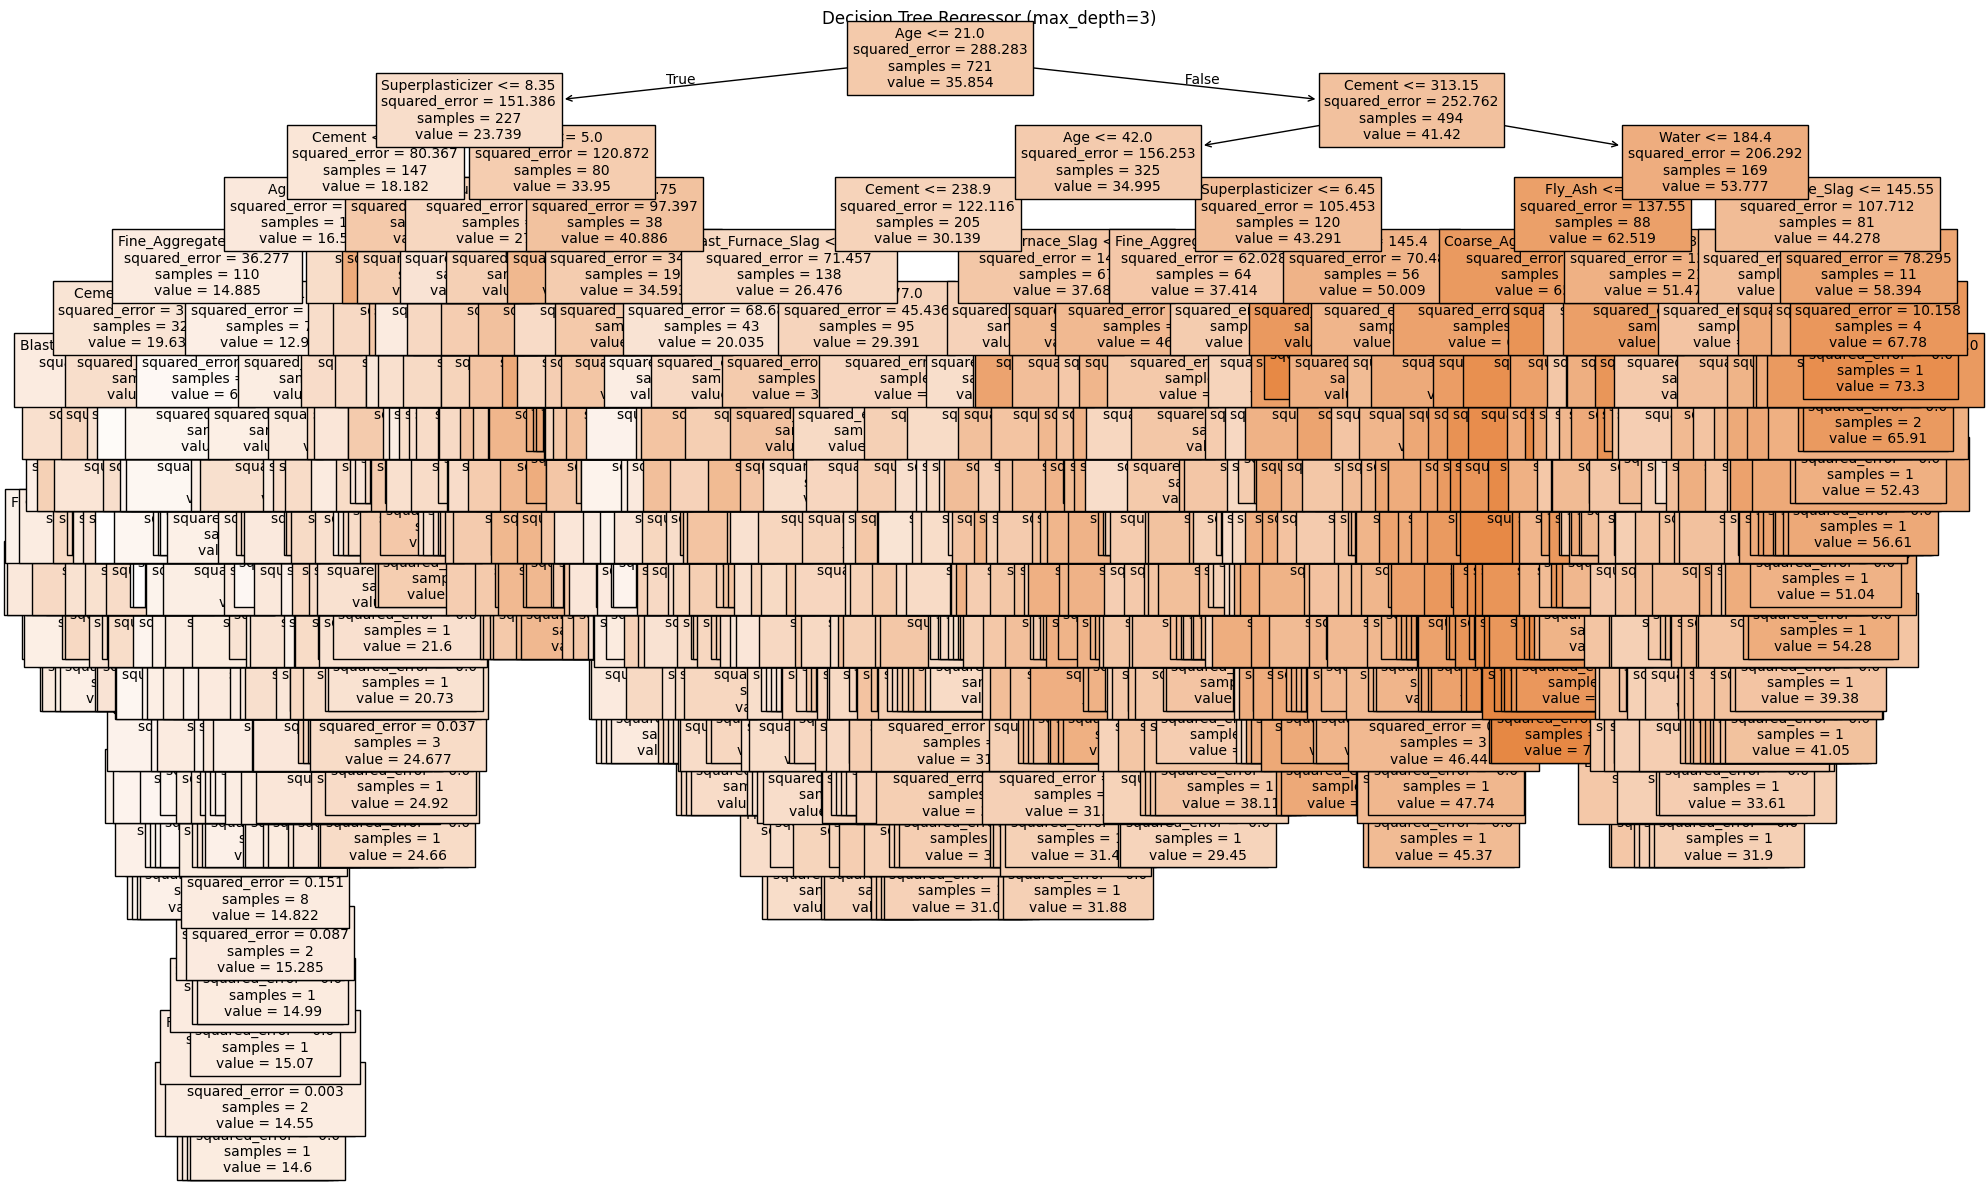

In [6]:
plt.figure(figsize=(20, 12))
tree.plot_tree(DT_reg1, filled=True, feature_names=X_reg.columns, fontsize=10)
plt.title("Decision Tree Regressor (max_depth=3)")
plt.tight_layout()
plt.show()

### 1-4) 예측 시각화

> 대각선(빨간 점선)에 가까울수록 예측이 정확함. 선형 회귀와 달리 의사결정나무는 끝 노드 개수만큼의 계단 형태 예측값을 가짐

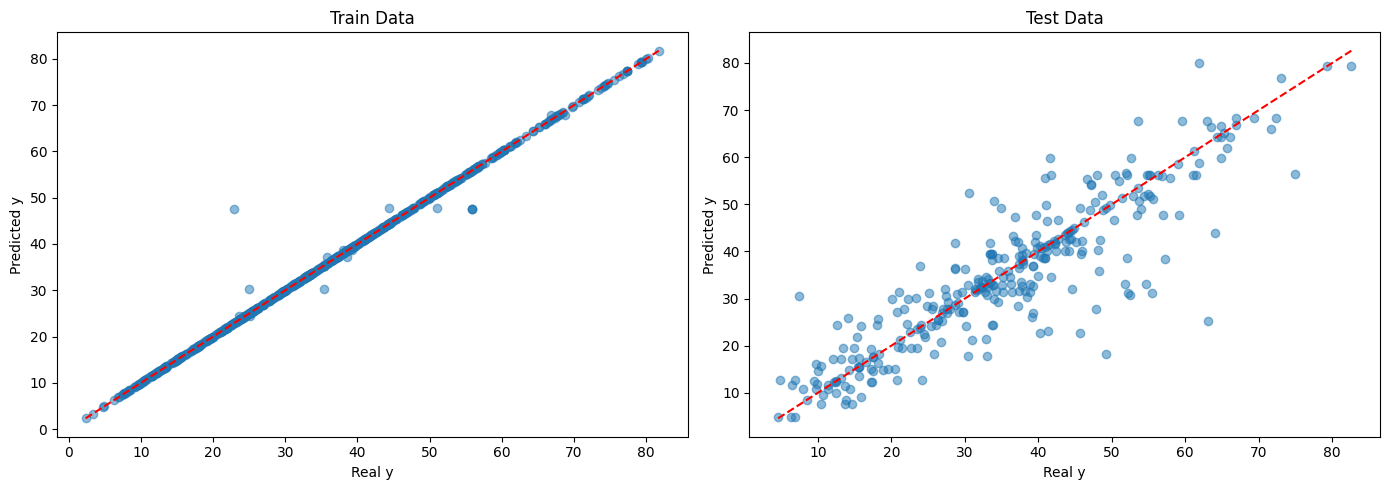

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(Y_reg_train, DT_reg1.predict(X_reg_train), alpha=0.5)
axes[0].plot([Y_reg_train.min(), Y_reg_train.max()],
             [Y_reg_train.min(), Y_reg_train.max()], "r--")
axes[0].set_xlabel("Real y")
axes[0].set_ylabel("Predicted y")
axes[0].set_title("Train Data")

axes[1].scatter(Y_reg_test, DT_reg1_pred, alpha=0.5)
axes[1].plot([Y_reg_test.min(), Y_reg_test.max()],
             [Y_reg_test.min(), Y_reg_test.max()], "r--")
axes[1].set_xlabel("Real y")
axes[1].set_ylabel("Predicted y")
axes[1].set_title("Test Data")

plt.tight_layout()
plt.show()

### 1-5) max_depth에 따른 과적합 확인

> 나무가 과하게 깊어지면(max_depth가 커지면) 학습 데이터에 **과적합**되어 테스트 데이터의 성능이 떨어질 수 있음

In [8]:
DT_reg2 = DecisionTreeRegressor(random_state=0, max_depth=10)
DT_reg2.fit(X_reg_train, Y_reg_train)
DT_reg2_pred = DT_reg2.predict(X_reg_test)

DT_reg3 = DecisionTreeRegressor(random_state=0, max_depth=5)
DT_reg3.fit(X_reg_train, Y_reg_train)
DT_reg3_pred = DT_reg3.predict(X_reg_test)

print("=== max_depth=None ===")
get_regscore(Y_reg_test, DT_reg1_pred)
print()
print("=== max_depth=10 ===")
get_regscore(Y_reg_test, DT_reg2_pred)
print()
print("=== max_depth=5 ===")
get_regscore(Y_reg_test, DT_reg3_pred)
print()
print("=== Day 2-1 다중선형회귀 참고 ===")
print("RMSE      : 9.676")
print("R-squared : 0.635")

=== max_depth=None ===
MSE       : 54.841
RMSE      : 7.405
MAE       : 4.787
R-squared : 0.786

=== max_depth=10 ===
MSE       : 56.136
RMSE      : 7.492
MAE       : 4.900
R-squared : 0.781

=== max_depth=5 ===
MSE       : 82.974
RMSE      : 9.109
MAE       : 6.894
R-squared : 0.677

=== Day 2-1 다중선형회귀 참고 ===
RMSE      : 9.676
R-squared : 0.635


---

## 2) 의사결정나무 분류 (Classification)

> 의사결정나무 **분류**에서는 **지니 불순도(Gini Impurity)** 를 기준으로 데이터를 가장 잘 구분하는 입력변수와 경계 값을 선택함
> - $Gini(S) = 1 - \sum_{i=1}^{c} p_i^2$ (불순도가 0이면 완벽히 분류된 상태)
> - **정보 이득(Information Gain)** 이 가장 큰 변수로 노드를 분할함
> - Day 2-2에서 학습한 로지스틱 회귀와 동일한 데이터로 성능을 비교함

### 2-1) 데이터 준비

> Day 2-2에서 사용한 제조 불량 데이터를 동일하게 사용함

In [9]:
MF_Data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day2-3_cls_data.csv"))

#MF_Data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/day2-3_data.csv")

# 입출력 변수 분할
Y = MF_Data["Failure"]
X = MF_Data.drop(["Failure"], axis=1)

# 범주형 변수 처리
X["Measure2"] = X["Measure2"].astype("category")
X["Measure3"] = X["Measure3"].astype("category")
X = pd.get_dummies(X)
data_columns = X.columns

# 출력변수 값 변경
Y = Y.replace({"No": 0, "Yes": 1}).astype(int)

# 학습/테스트 데이터 분할
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0, stratify=Y)

print("학습 데이터 크기   :", X_train.shape, Y_train.shape)
print("테스트 데이터 크기 :", X_test.shape, Y_test.shape)

학습 데이터 크기   : (5530, 31) (5530,)
테스트 데이터 크기 : (2370, 31) (2370,)


C:\Users\Admin\AppData\Local\Temp\ipykernel_14672\3403311988.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y = Y.replace({"No": 0, "Yes": 1}).astype(int)


In [10]:
# 분류 모형 성능 지표 산출 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % (accuracy_score(real, pred)))
    print("Precision : %.3f" % (precision_score(real, pred)))
    print("Recall    : %.3f" % (recall_score(real, pred)))
    print("F1-score  : %.3f" % (f1_score(real, pred)))
    print()
    print("혼동행렬")
    print(confusion_matrix(real, pred))

### 2-2) 모델 학습

In [11]:
DT_cla1 = DecisionTreeClassifier()
DT_cla1.fit(X_train, Y_train)
DT_cla1_pred = DT_cla1.predict(X_test)
get_classscore(Y_test, DT_cla1_pred)

Accuracy  : 0.995
Precision : 0.727
Recall    : 0.727
F1-score  : 0.727

혼동행렬
[[2342    6]
 [   6   16]]


### 2-3) 나무 시각화

> 의사결정나무의 큰 장점은 모델의 **분류 규칙을 직관적으로 이해**할 수 있다는 것임

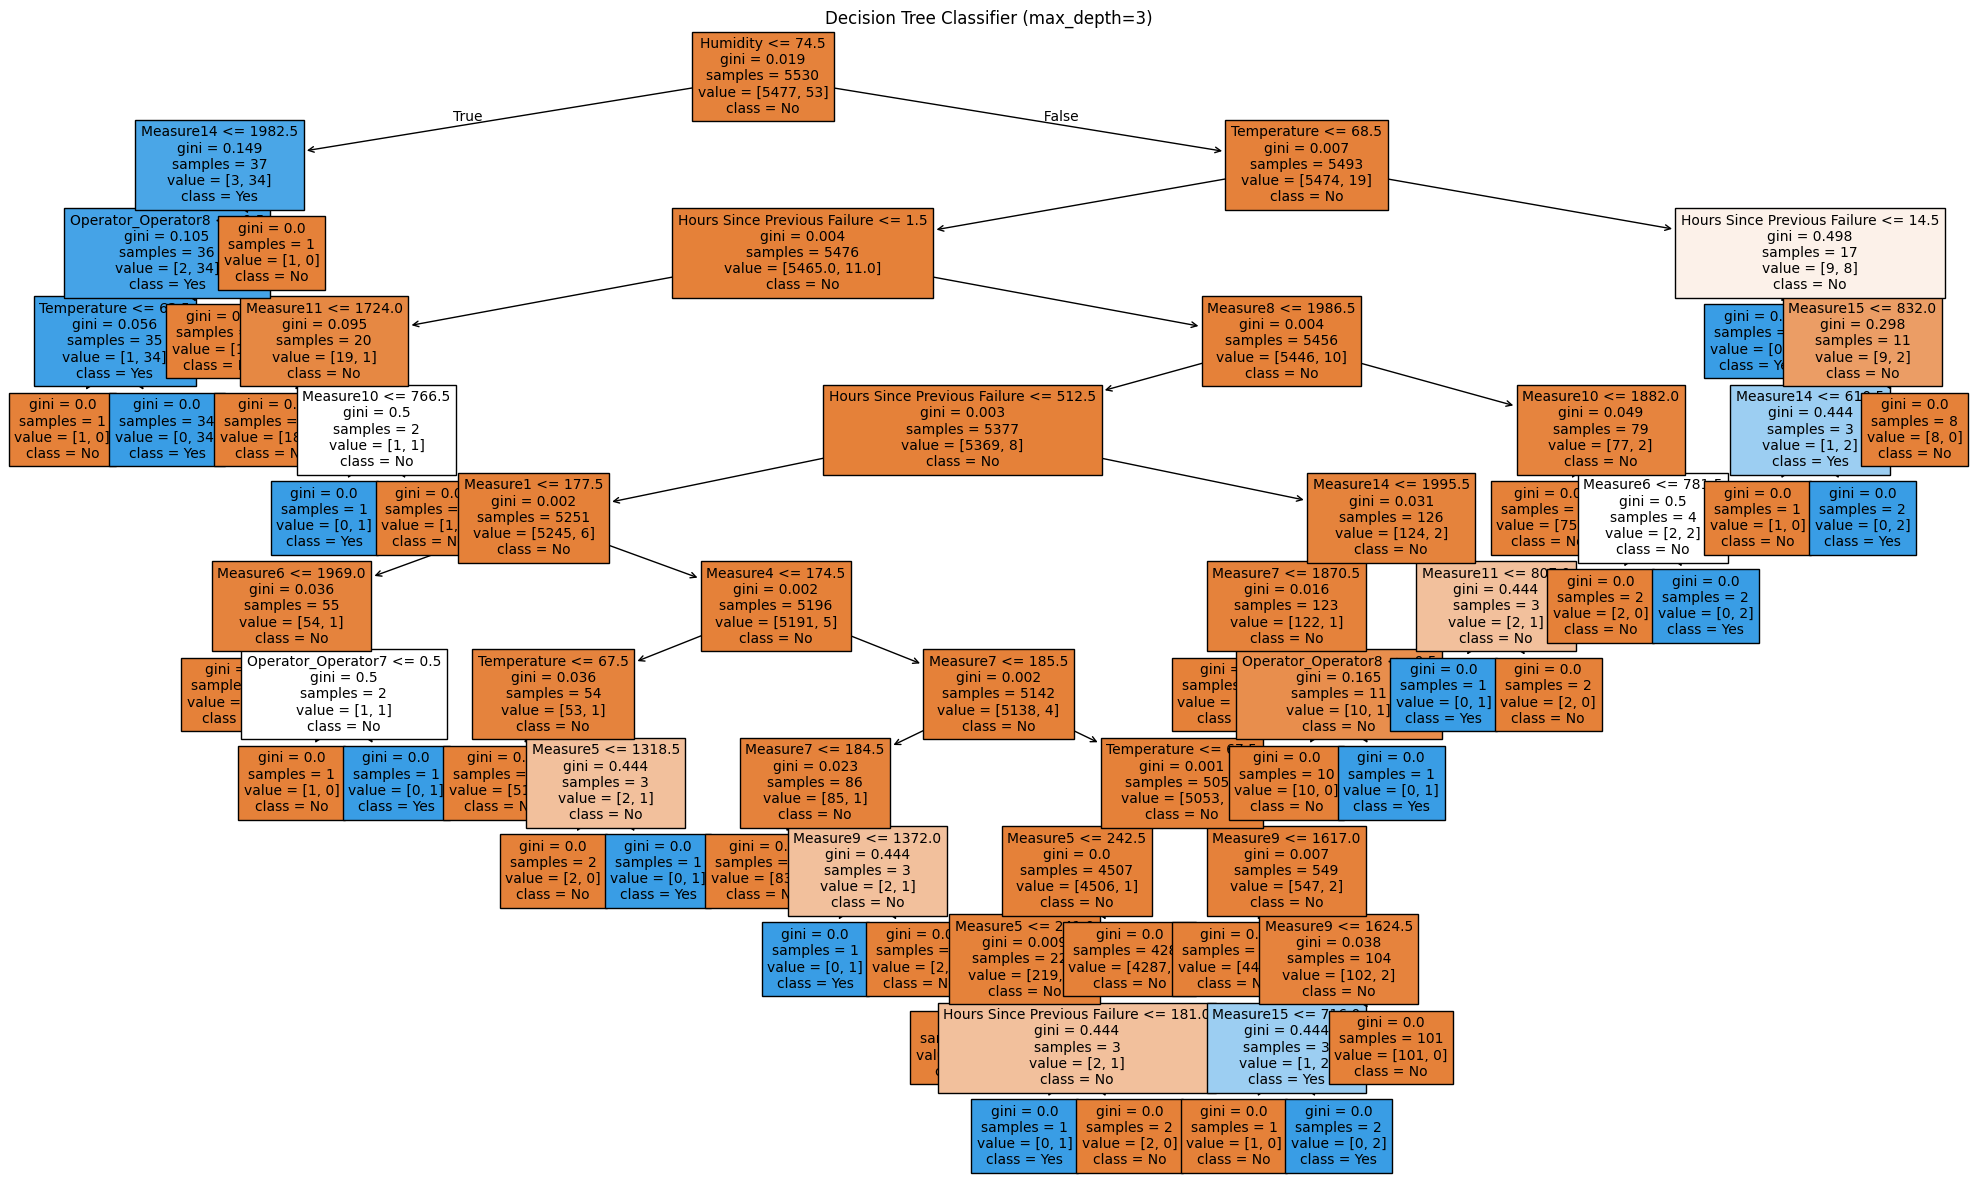

In [12]:
plt.figure(figsize=(20, 12))
tree.plot_tree(DT_cla1, class_names=["No", "Yes"],
               filled=True, feature_names=data_columns, fontsize=10)
plt.title("Decision Tree Classifier (max_depth=3)")
plt.tight_layout()
plt.show()

### 2-4) max_depth에 따른 과적합 확인

> 나무가 깊어지면(max_depth가 커지면) 학습 데이터에 **과적합**되어 테스트 데이터의 성능이 떨어질 수 있음
> - **사전 가지치기**: max_depth, max_leaf_nodes, min_samples_leaf 등을 설정하여 나무 성장을 제한
> - **사후 가지치기**: 완성된 나무에서 유의미하지 않은 가지를 제거 (ccp_alpha 사용)

In [13]:
# max_depth=10으로 변경
DT_cla2 = DecisionTreeClassifier(max_depth=10)
DT_cla2.fit(X_train, Y_train)
DT_cla2_pred = DT_cla2.predict(X_test)

print("=== max_depth=None ===")
get_classscore(Y_test, DT_cla1_pred)
print()
print("=== max_depth=10 ===")
get_classscore(Y_test, DT_cla2_pred)

=== max_depth=None ===
Accuracy  : 0.995
Precision : 0.727
Recall    : 0.727
F1-score  : 0.727

혼동행렬
[[2342    6]
 [   6   16]]

=== max_depth=10 ===
Accuracy  : 0.995
Precision : 0.739
Recall    : 0.773
F1-score  : 0.756

혼동행렬
[[2342    6]
 [   5   17]]


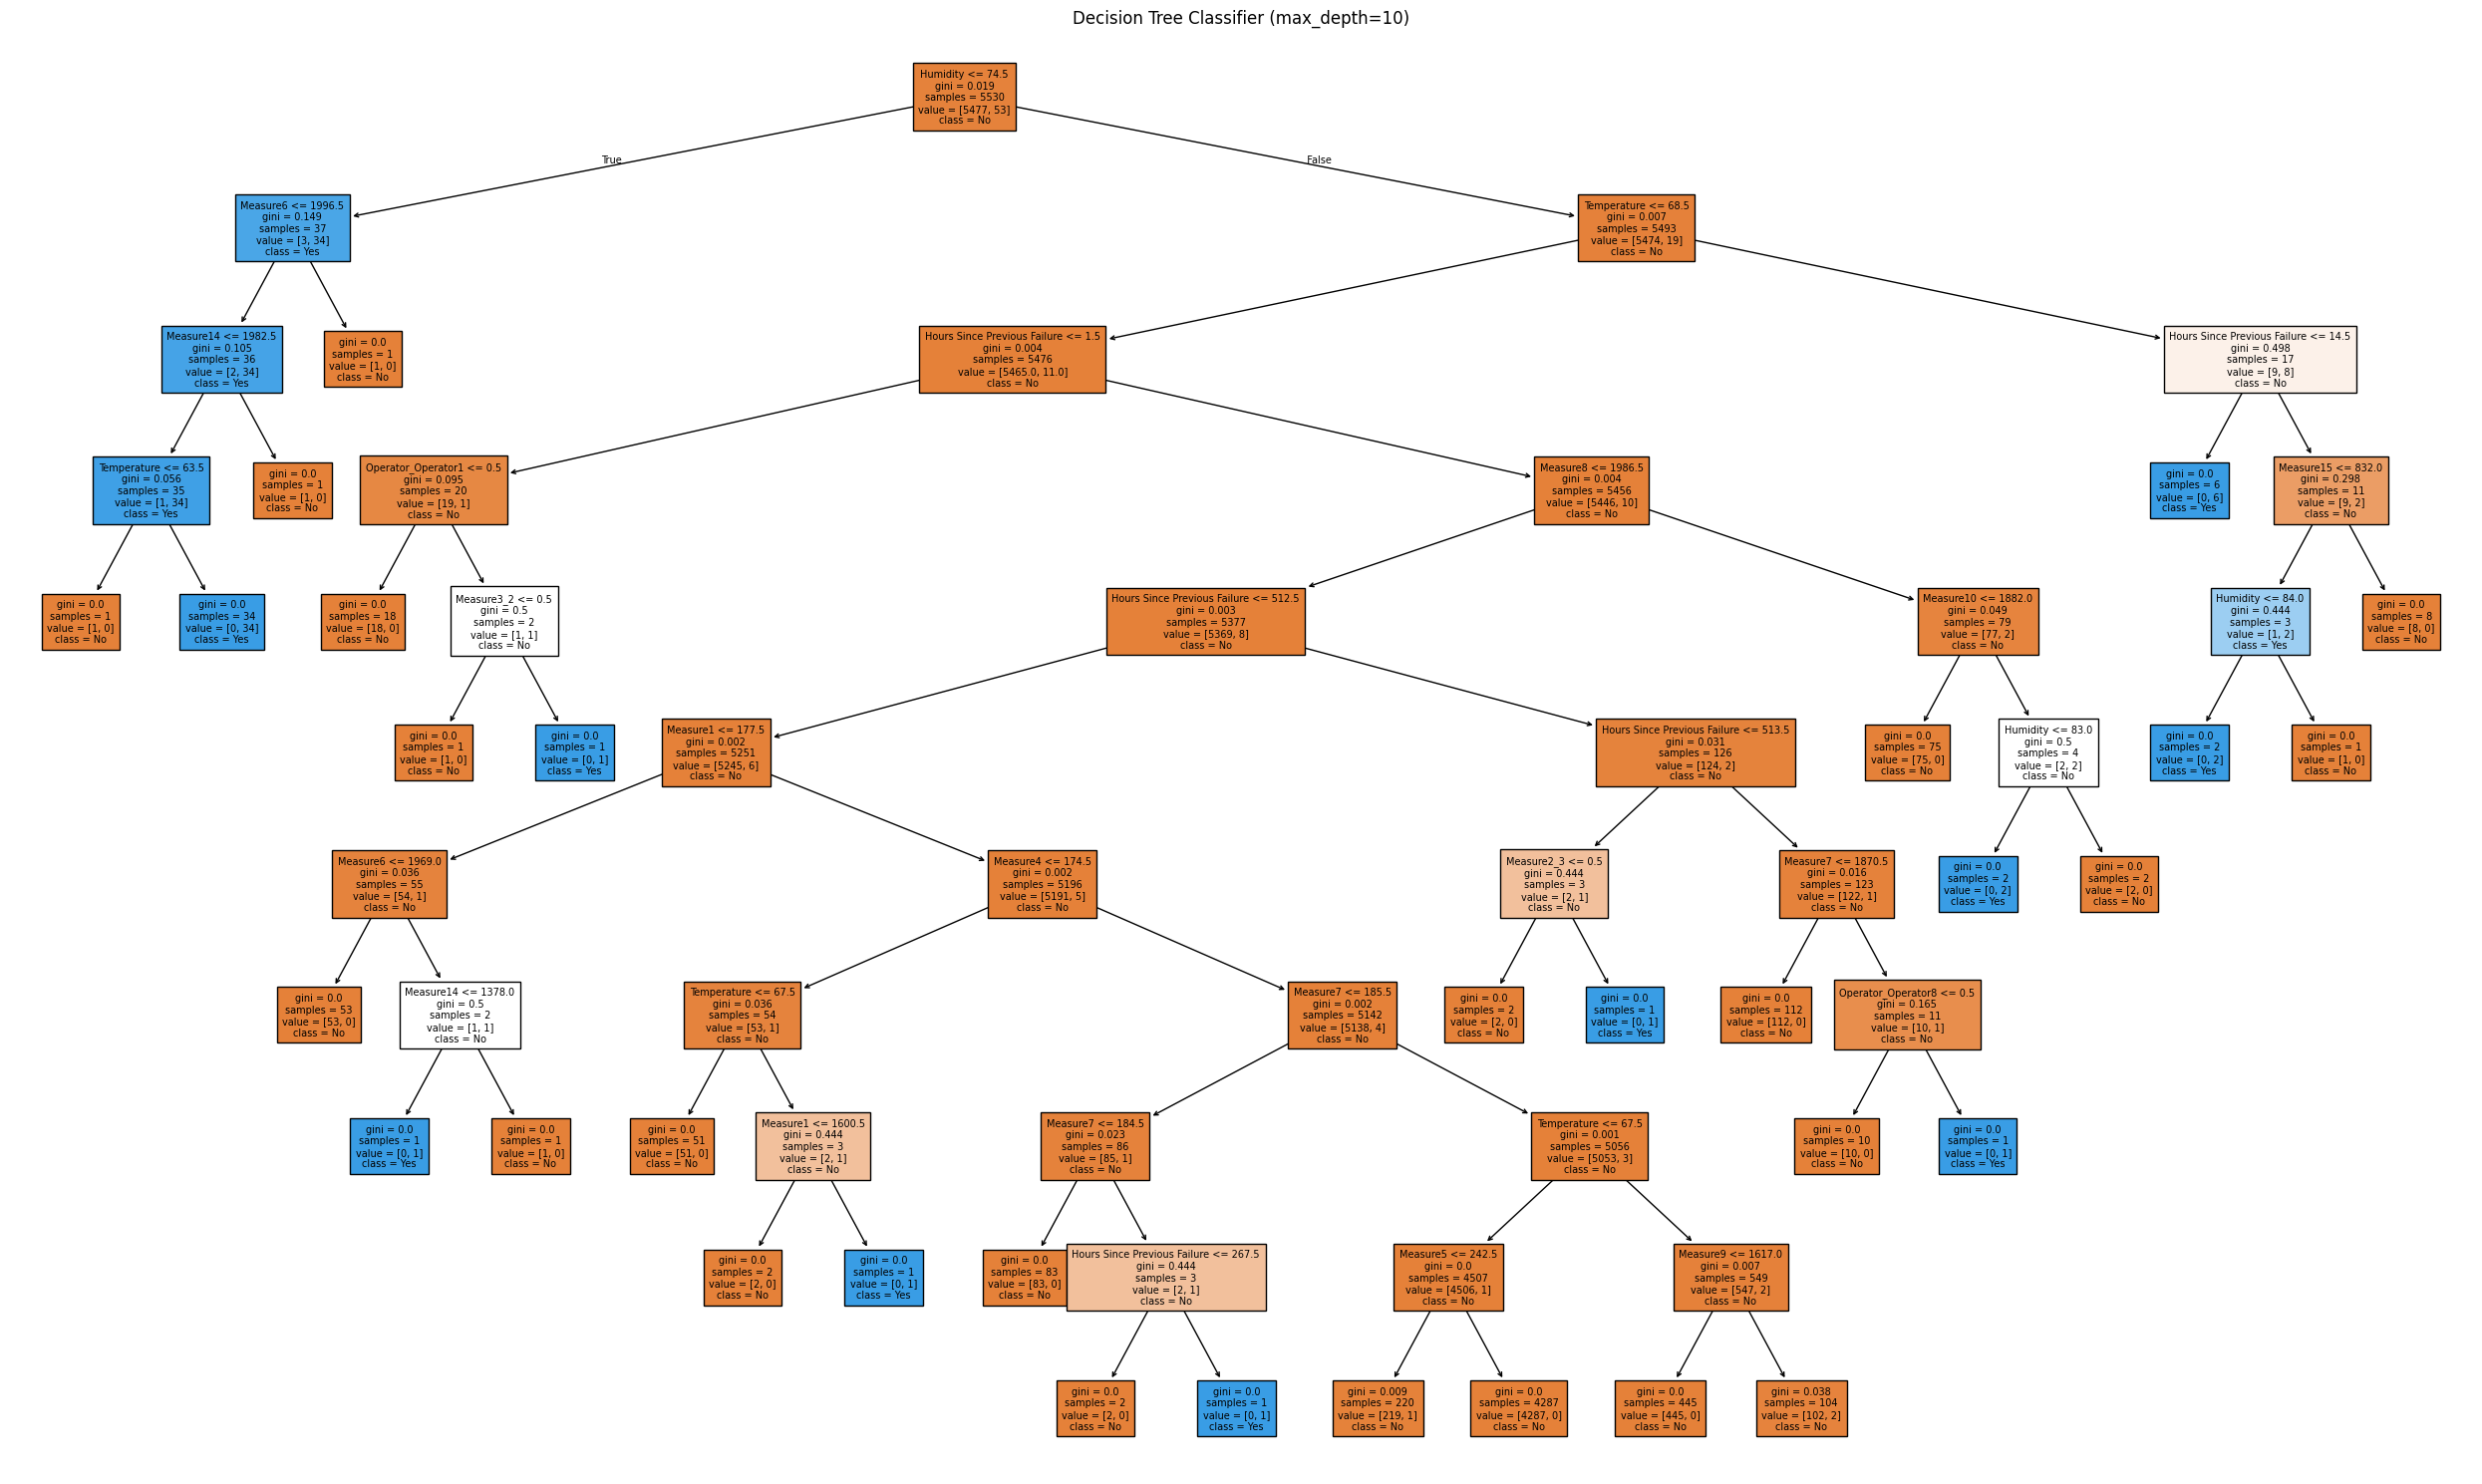

In [14]:
# 나무 시각화 (복잡한 나무)
plt.figure(figsize=(25, 15))
tree.plot_tree(DT_cla2, class_names=["No", "Yes"],
               filled=True, feature_names=data_columns, fontsize=7)
plt.title("Decision Tree Classifier (max_depth=10)")
plt.tight_layout()
plt.show()

### 2-5) 가지치기를 통한 과적합 방지

> max_depth=10 모델은 과적합되어 F1 Score가 크게 떨어졌음
> - **사전 가지치기**: min_samples_leaf를 설정하여 나무 성장을 제한
> - **사후 가지치기**: ccp_alpha를 사용하여 완성된 나무에서 불필요한 가지를 제거

In [15]:
# 사전 가지치기
DT_pre = DecisionTreeClassifier(max_depth=10, min_samples_leaf=3)
DT_pre.fit(X_train, Y_train)
DT_pre_pred = DT_pre.predict(X_test)

print("=== 사전 가지치기 (max_depth=10, min_samples_leaf=5) ===")
get_classscore(Y_test, DT_pre_pred)

=== 사전 가지치기 (max_depth=10, min_samples_leaf=5) ===
Accuracy  : 0.997
Precision : 0.889
Recall    : 0.727
F1-score  : 0.800

혼동행렬
[[2346    2]
 [   6   16]]


> ccp_alpha는 비교하고자 하는 성능지표가 가장 높은 지점을 선택하며, alpha가 너무 크면 나무가 과도하게 잘려 underfitting됨

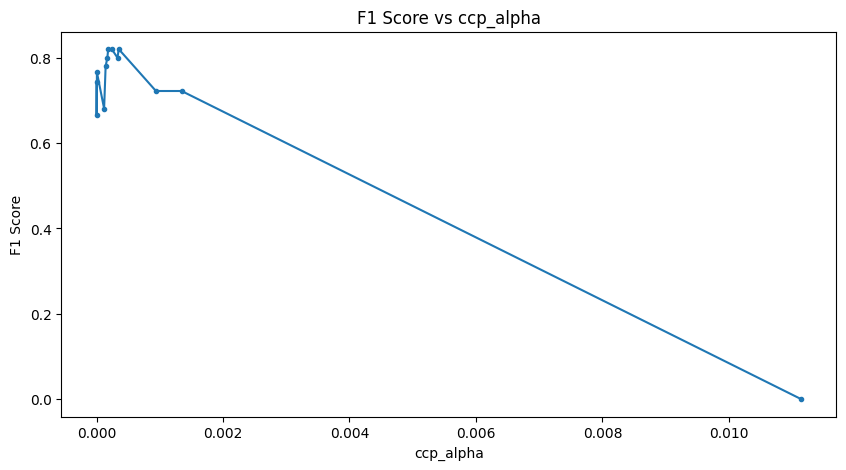

최적 ccp_alpha: 0.00018

=== 사전 가지치기  ===
Accuracy  : 0.997
Precision : 0.889
Recall    : 0.727
F1-score  : 0.800

혼동행렬
[[2346    2]
 [   6   16]]

=== 사후 가지치기 (ccp_alpha=0.00018) ===
Accuracy  : 0.997
Precision : 0.941
Recall    : 0.727
F1-score  : 0.821

혼동행렬
[[2347    1]
 [   6   16]]


In [16]:
# 사후 가지치기: ccp_alpha별 테스트 F1 score 비교
path = DT_cla2.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas = path.ccp_alphas

f1_scores = []
for alpha in ccp_alphas:
    dt = DecisionTreeClassifier(ccp_alpha=alpha)
    dt.fit(X_train, Y_train)
    pred = dt.predict(X_test)
    f1_scores.append(f1_score(Y_test, pred))

plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas, f1_scores, marker="o", markersize=3)
plt.xlabel("ccp_alpha")
plt.ylabel("F1 Score")
plt.title("F1 Score vs ccp_alpha")
plt.show()

best_idx = np.argmax(f1_scores)
print("최적 ccp_alpha:", round(ccp_alphas[best_idx], 5))

# 최적 ccp_alpha로 모델 학습 및 성능 비교
best_alpha = ccp_alphas[best_idx]
DT_post = DecisionTreeClassifier(ccp_alpha=best_alpha)
DT_post.fit(X_train, Y_train)
DT_post_pred = DT_post.predict(X_test)

print("\n=== 사전 가지치기  ===")
get_classscore(Y_test, DT_pre_pred)
print()
print(f"=== 사후 가지치기 (ccp_alpha={best_alpha:.5f}) ===")
get_classscore(Y_test, DT_post_pred)

---

## 3) 하이퍼 파라미터 최적화

> 의사결정나무의 주요 하이퍼 파라미터:
>
> | 파라미터 | 의미 |
> |:---:|:---:|
> | max_depth | 트리의 최대 깊이 |
> | max_leaf_nodes | 끝 노드(Leaf)의 최대 개수 |
> | min_samples_leaf | 끝 노드가 되기 위한 최소 샘플 수 |
> | min_samples_split | 노드를 분할하기 위한 최소 샘플 수 |
> | ccp_alpha | 사후 가지치기 강도 (값이 클수록 가지를 많이 제거) |

### 3-1) Grid Search

> **Grid Search**는 하이퍼 파라미터의 모든 조합을 탐색하여 최적의 조합을 찾는 방법임

In [17]:
from sklearn.model_selection import ParameterGrid

# 하이퍼파라미터 그리드 설정
params = {
    "max_depth": range(1, 20, 5),
    "min_samples_leaf": [6, 8, 10],
    "min_samples_split": [6, 8, 10],
    "ccp_alpha": [0, 0.001, 0.005, 0.01]
}

param_grid = list(ParameterGrid(params))
score_list = []

for param in param_grid:
    dt = DecisionTreeClassifier(**param)
    dt.fit(X_train, Y_train)
    y_pred = dt.predict(X_test)
    score = f1_score(Y_test, y_pred)
    score_list.append(score)

print("최적의 하이퍼파라미터:", param_grid[np.argmax(score_list)])
print("최적의 성능 (F1 score):", np.round(np.max(score_list), 4))

최적의 하이퍼파라미터: {'ccp_alpha': 0, 'max_depth': 6, 'min_samples_leaf': 8, 'min_samples_split': 6}
최적의 성능 (F1 score): 0.8293


### 3-2) 최적 모델 학습

In [18]:
# 최적 하이퍼파라미터로 모델 재학습
best_params = param_grid[np.argmax(score_list)]

DT_best = DecisionTreeClassifier(**best_params)
DT_best.fit(X_train, Y_train)
DT_best_predict = DT_best.predict(X_test)
get_classscore(Y_test, DT_best_predict)

Accuracy  : 0.997
Precision : 0.895
Recall    : 0.773
F1-score  : 0.829

혼동행렬
[[2346    2]
 [   5   17]]


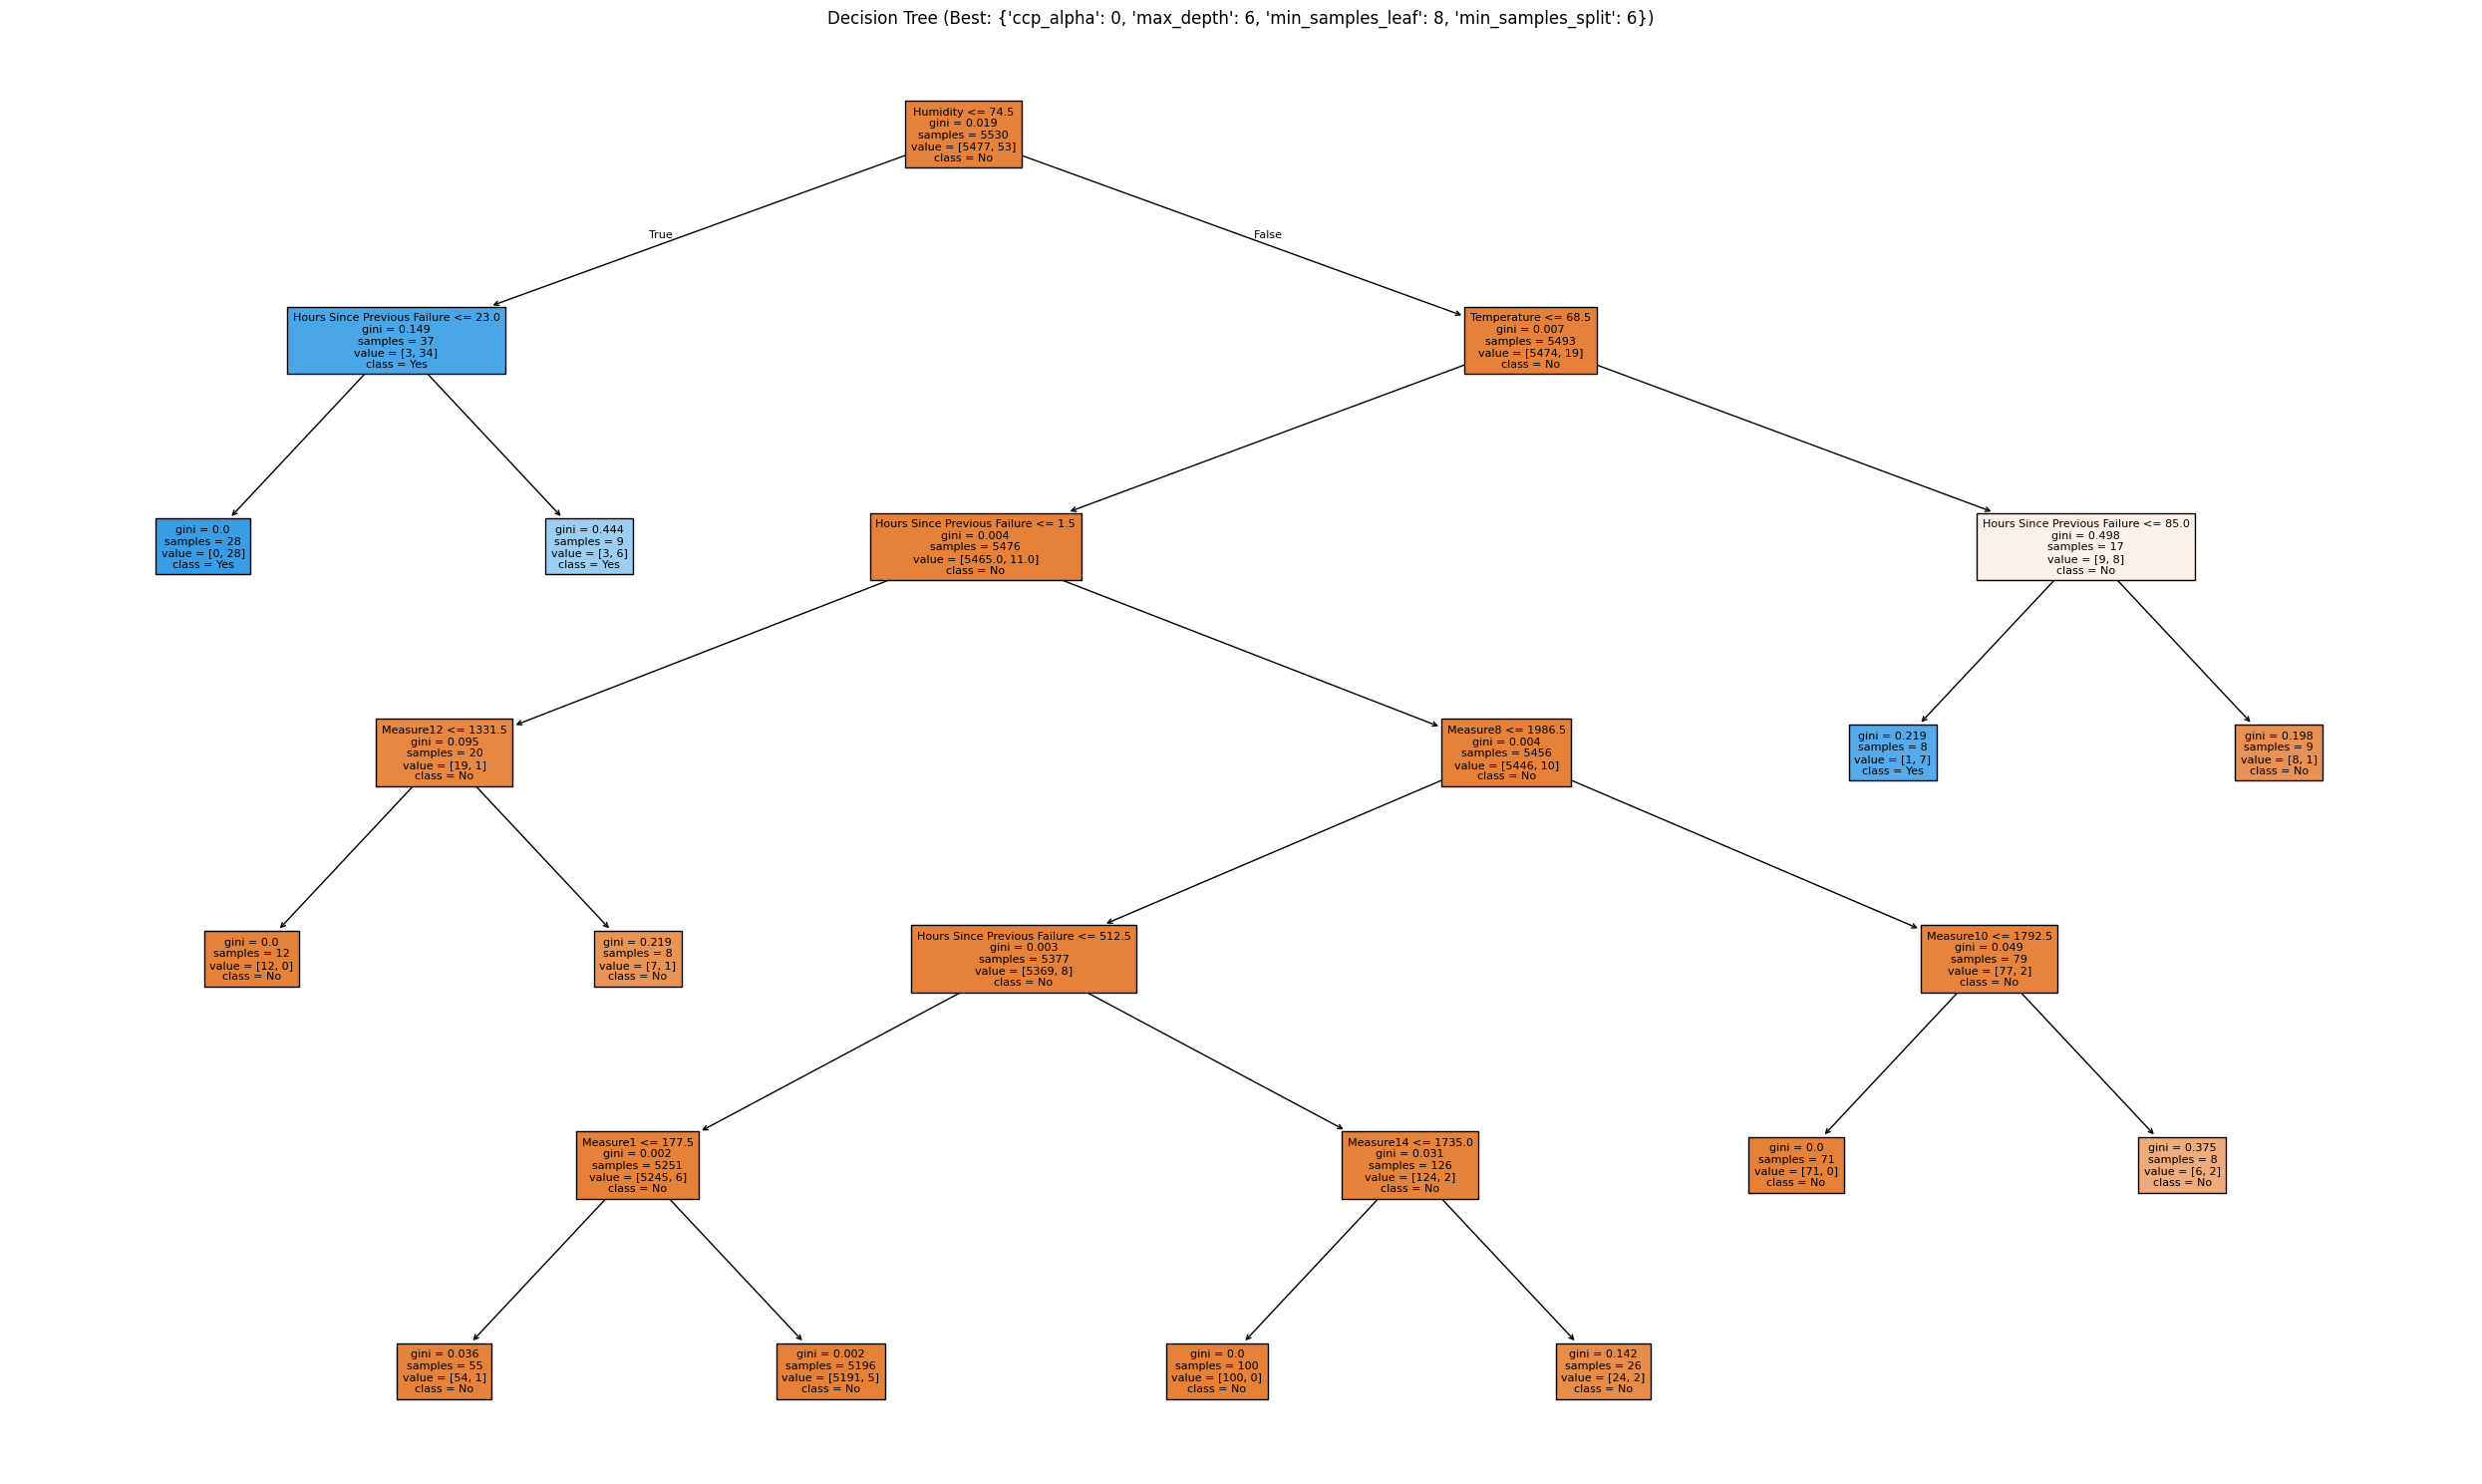

In [19]:
# 최적 모델 나무 시각화
plt.figure(figsize=(25, 15))
tree.plot_tree(DT_best, class_names=["No", "Yes"],
               filled=True, feature_names=data_columns, fontsize=8)
plt.title(f"Decision Tree (Best: {best_params})")
plt.tight_layout()
plt.show()

---

## 4) Vibe Coding 실습

### 4-1) 회귀 / 분류 나무 심화

**[과제 1]** 지수는 회귀 나무 모델의 깊이가 너무 깊어지면 과적합이 발생할 수 있다는 점을 알게 되었습니다. AI와 함께 적절한 트리 깊이를 찾는 방법을 알아보고, 다양한 깊이에서의 성능을 비교하여 가장 적절한 깊이를 찾아보세요.

[회귀] CV RMSE 기준 최적 max_depth = 12
 max_depth  Train RMSE  Test RMSE  CV RMSE
         1      14.861     13.548   14.882
         2      12.190     12.349   12.929
         3      10.006     10.606   10.667
         4       8.361      9.914    9.650
         5       6.682      9.109    8.920
         6       5.326      8.304    8.204
         7       4.069      7.819    7.974
         8       3.046      7.674    7.934
         9       2.413      7.632    7.850
        10       1.880      7.492    7.791
        11       1.445      7.409    8.020
        12       1.250      7.423    7.657
        13       1.171      7.311    7.948
        14       1.132      7.566    7.708
        15       1.121      7.535    7.946
        16       1.118      7.396    7.989
        17       1.118      7.570    8.046
        18       1.117      7.466    7.920
        19       1.117      7.379    7.982
        20       1.117      7.304    7.982


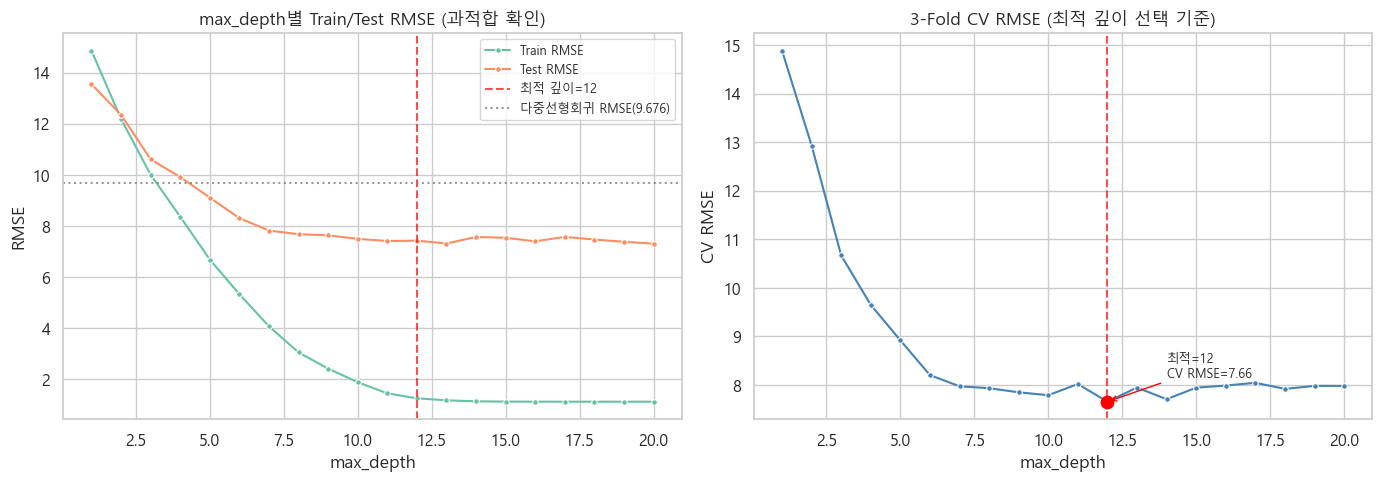


[해석]
- max_depth=12에서 CV RMSE가 최소 (7.657)
- Test RMSE 7.423 → Day 2-1 다중선형회귀(9.676)보다 우수
- 깊이가 커질수록 Train RMSE↓, Test RMSE↑ 패턴 → 과적합 발생
- max_depth를 제한하면(사전 가지치기) 일반화 성능을 개선할 수 있음


In [20]:
# ============================================================
# [과제 1] 회귀 나무 적절한 깊이(max_depth) 탐색
# ------------------------------------------------------------
# 방법: 3-fold CV로 Train/Test RMSE를 함께 비교 → 과적합 구간 확인
#       CV RMSE가 최소인 깊이를 최적 깊이로 선택
# ============================================================
import matplotlib.font_manager as fm
from sklearn.model_selection import cross_validate

def setup_korean_font():
    """matplotlib/seaborn 한글 폰트 적용. sns.set_theme() 호출 후 재호출 필요."""
    _korean_fonts = ["Malgun Gothic", "NanumGothic", "AppleGothic", "Gulim"]
    _available = {f.name for f in fm.fontManager.ttflist}
    for _font in _korean_fonts:
        if _font in _available:
            plt.rcParams["font.family"] = _font
            break
    plt.rcParams["axes.unicode_minus"] = False

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
setup_korean_font()

depth_range = range(1, 21)
reg_depth_rows = []

for depth in depth_range:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=0)
    cv_result = cross_validate(
        dt, X_reg_train, Y_reg_train, cv=3,
        scoring="neg_root_mean_squared_error",
        return_train_score=True, n_jobs=-1,
    )
    dt.fit(X_reg_train, Y_reg_train)
    reg_depth_rows.append({
        "max_depth": depth,
        "Train RMSE": np.sqrt(mean_squared_error(Y_reg_train, dt.predict(X_reg_train))),
        "Test RMSE": np.sqrt(mean_squared_error(Y_reg_test, dt.predict(X_reg_test))),
        "CV RMSE": -cv_result["test_score"].mean(),
    })

reg_depth_df = pd.DataFrame(reg_depth_rows)
vc_best_depth = int(reg_depth_df.loc[reg_depth_df["CV RMSE"].idxmin(), "max_depth"])

print("=" * 60)
print(f"[회귀] CV RMSE 기준 최적 max_depth = {vc_best_depth}")
print("=" * 60)
print(reg_depth_df.round(3).to_string(index=False))

# 시각화: Train vs Test RMSE (과적합 확인) + CV RMSE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reg_melt = reg_depth_df.melt(
    id_vars="max_depth", value_vars=["Train RMSE", "Test RMSE"],
    var_name="구분", value_name="RMSE",
)
sns.lineplot(data=reg_melt, x="max_depth", y="RMSE", hue="구분",
             marker="o", markersize=4, ax=axes[0])
axes[0].axvline(vc_best_depth, color="red", linestyle="--", alpha=0.7,
                label=f"최적 깊이={vc_best_depth}")
axes[0].axhline(9.676, color="gray", linestyle=":", alpha=0.8, label="다중선형회귀 RMSE(9.676)")
axes[0].set_title("max_depth별 Train/Test RMSE (과적합 확인)")
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("RMSE")
axes[0].legend(fontsize=9)

sns.lineplot(data=reg_depth_df, x="max_depth", y="CV RMSE",
             marker="o", markersize=4, color="steelblue", ax=axes[1])
axes[1].axvline(vc_best_depth, color="red", linestyle="--", alpha=0.7)
best_cv = reg_depth_df.loc[reg_depth_df["CV RMSE"].idxmin()]
axes[1].scatter([vc_best_depth], [best_cv["CV RMSE"]], color="red", s=80, zorder=5)
axes[1].annotate(f"최적={vc_best_depth}\nCV RMSE={best_cv['CV RMSE']:.2f}",
                 xy=(vc_best_depth, best_cv["CV RMSE"]),
                 xytext=(vc_best_depth + 2, best_cv["CV RMSE"] + 0.5),
                 arrowprops=dict(arrowstyle="->", color="red"), fontsize=9)
axes[1].set_title("3-Fold CV RMSE (최적 깊이 선택 기준)")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("CV RMSE")

plt.tight_layout()
plt.show()

# 해석
best_row = reg_depth_df[reg_depth_df["max_depth"] == vc_best_depth].iloc[0]
gap = best_row["Train RMSE"] - best_row["Test RMSE"]
print("\n[해석]")
print(f"- max_depth={vc_best_depth}에서 CV RMSE가 최소 ({best_row['CV RMSE']:.3f})")
print(f"- Test RMSE {best_row['Test RMSE']:.3f} → Day 2-1 다중선형회귀(9.676)보다 {'우수' if best_row['Test RMSE'] < 9.676 else '열등'}")
print(f"- 깊이가 커질수록 Train RMSE↓, Test RMSE↑ 패턴 → 과적합 발생")
print(f"- max_depth를 제한하면(사전 가지치기) 일반화 성능을 개선할 수 있음")

### 4-2) 모델 결과 해석 심화

**[과제 2]** 지수는 회귀 나무와 분류 나무가 어떤 변수를 중요하게 사용하여 데이터를 분할하는지 궁금해졌습니다. AI와 함께 각 모델의 주요 변수를 확인하고, 해당 변수가 중요한 이유를 분할 기준 및 변수명과 함께 해석해 보세요. 또한 트리 구조를 살펴보며 데이터의 특성을 설명할 수 있는 의사결정 규칙을 직접 도출해 보세요.

[회귀] 변수 중요도 Top 5
                변수    중요도  누적중요도
               Age 0.3384 0.3384
            Cement 0.2897 0.6281
             Water 0.1037 0.7318
  Superplasticizer 0.0928 0.8245
Blast_Furnace_Slag 0.0667 0.8912

[분류] 변수 중요도 Top 5
                          변수    중요도  누적중요도
                    Humidity 0.7994 0.7994
                 Temperature 0.0966 0.8960
Hours Since Previous Failure 0.0857 0.9817
                   Measure10 0.0117 0.9933
                   Measure14 0.0032 0.9965


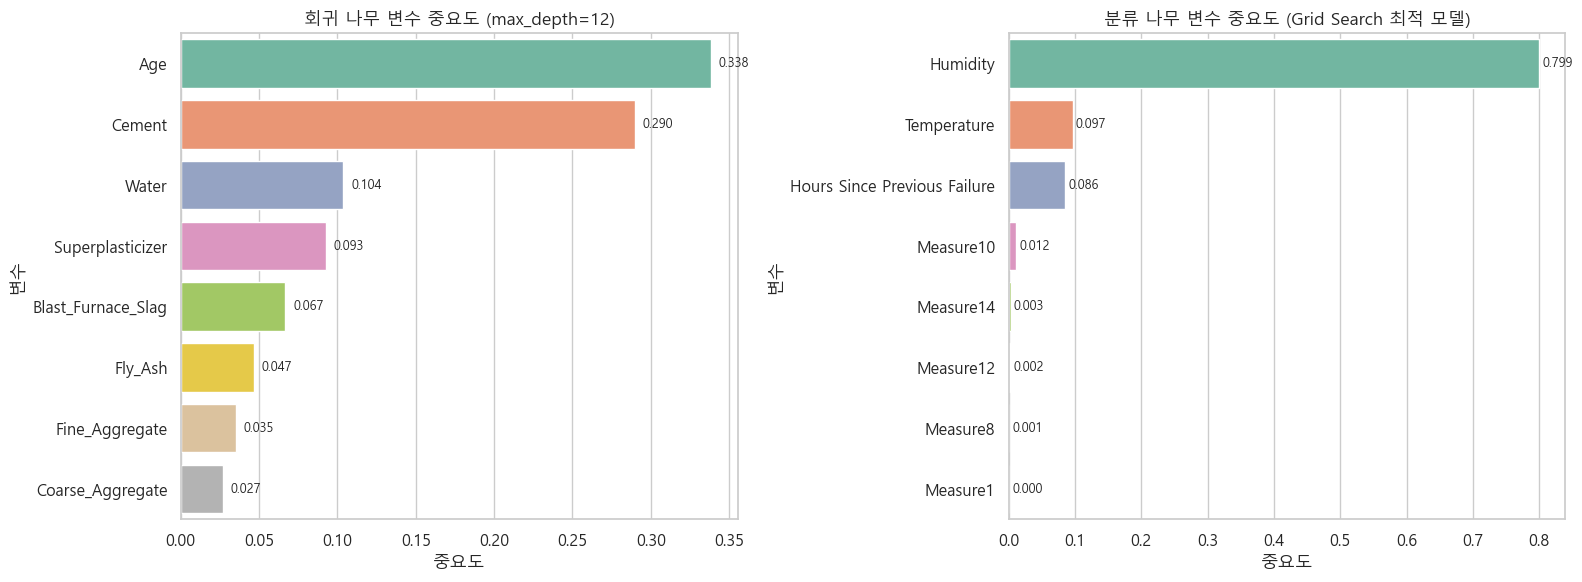


[회귀] 주요 분할 규칙 (상위 3 depth)
|--- Age <= 21.00
|   |--- Superplasticizer <= 8.35
|   |   |--- Cement <= 434.00
|   |   |   |--- Age <= 10.50
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- Age >  10.50
|   |   |   |   |--- truncated branch of depth 9
|   |   |--- Cement >  434.00
|   |   |   |--- Water <= 181.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Water >  181.00
|   |   |   |   |--- truncated branch of depth 7
|   |--- Superplasticizer >  8.35
|   |   |--- Age <= 5.00
|   |   |   |--- Blast_Furnace_Slag <= 19.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- Blast_Furnace_Slag >  19.50
|   |   |   |   |--- truncated branch of depth 8
|   |   |--- Age >  5.00
|   |   |   |--- Fly_Ash <= 51.75
|   |   |   |   |--- truncated branch of depth 8
|   |   |   |--- Fly_Ash >  51.75
|   |   |   |   |--- truncated branch of depth 8
|--- Age >  21.00
|   |--- Cement <= 313.15
|   |   |--- Age <= 42.00
|   |   |   |--- Cement <= 238

In [21]:
# ============================================================
# [과제 2] 변수 중요도 & 의사결정 규칙 해석
# ------------------------------------------------------------
# feature_importances_ : 분할에 기여한 정도 (Gini/분산 감소량 기반)
# export_text          : 상위 분기 규칙을 텍스트로 추출
# ============================================================
from sklearn.tree import export_text

setup_korean_font()

# --- 회귀 나무 (과제1 최적 깊이) ---
vc_reg_tree = DecisionTreeRegressor(max_depth=vc_best_depth, random_state=0)
vc_reg_tree.fit(X_reg_train, Y_reg_train)

vc_imp_reg = (
    pd.DataFrame({"변수": X_reg.columns, "중요도": vc_reg_tree.feature_importances_})
    .sort_values("중요도", ascending=False)
    .reset_index(drop=True)
)
vc_imp_reg["누적중요도"] = vc_imp_reg["중요도"].cumsum()

# --- 분류 나무 (섹션 3-2 최적 모델) ---
vc_imp_cls = (
    pd.DataFrame({"변수": data_columns, "중요도": DT_best.feature_importances_})
    .sort_values("중요도", ascending=False)
    .reset_index(drop=True)
)
vc_imp_cls["누적중요도"] = vc_imp_cls["중요도"].cumsum()

print("=" * 60)
print("[회귀] 변수 중요도 Top 5")
print("=" * 60)
print(vc_imp_reg.head(5).round(4).to_string(index=False))
print("\n" + "=" * 60)
print("[분류] 변수 중요도 Top 5")
print("=" * 60)
print(vc_imp_cls.head(5).round(4).to_string(index=False))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_reg = vc_imp_reg.head(8)
sns.barplot(data=top_reg, x="중요도", y="변수", hue="변수", ax=axes[0], legend=False)
axes[0].set_title(f"회귀 나무 변수 중요도 (max_depth={vc_best_depth})")
for i, v in enumerate(top_reg["중요도"]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

top_cls = vc_imp_cls.head(8)
sns.barplot(data=top_cls, x="중요도", y="변수", hue="변수", ax=axes[1], legend=False, palette="Set2")
axes[1].set_title("분류 나무 변수 중요도 (Grid Search 최적 모델)")
for i, v in enumerate(top_cls["중요도"]):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# --- 의사결정 규칙 (상위 3단계) ---
print("\n" + "=" * 60)
print("[회귀] 주요 분할 규칙 (상위 3 depth)")
print("=" * 60)
print(export_text(vc_reg_tree, feature_names=list(X_reg.columns), max_depth=3))

print("\n" + "=" * 60)
print("[분류] 주요 분할 규칙 (상위 3 depth)")
print("=" * 60)
print(export_text(DT_best, feature_names=list(data_columns), max_depth=3))

# --- 해석 ---
reg_ko = {
    "Cement": "시멘트", "Age": "양생기간", "Water": "물",
    "Superplasticizer": "감수제", "Blast_Furnace_Slag": "고로슬래그",
    "Fly_Ash": "플라이애시", "Coarse_Aggregate": "굵은골재", "Fine_Aggregate": "잔골재",
}
top_reg_var = vc_imp_reg.iloc[0]["변수"]
top_cls_var = vc_imp_cls.iloc[0]["변수"]

print("\n[해석 — 회귀]")
print(f"1) '{top_reg_var}'({reg_ko.get(top_reg_var, top_reg_var)})가 가장 중요 → "
      f"콘크리트 배합·양생 조건이 강도를 좌우하는 핵심 변수")
print(f"2) Age(양생기간)는 비선형 분할로 포착 → 선형회귀보다 나무가 유리한 이유")
print(f"3) 규칙 예: Age ≤ X → 저강도 구간 / Age > X & Cement > Y → 고강도 구간")

print("\n[해석 — 분류]")
print(f"1) '{top_cls_var}'가 최상위 분할 변수 → 공정 측정값이 불량 여부를 가장 먼저 구분")
print(f"2) Measure2/Measure3 더미 변수도 상위권 → 범주형 공정 상태가 불량과 연관")
print(f"3) IF-THEN 규칙으로 '어떤 측정값 범위에서 불량 위험이 높은지' 현장 설명 가능")

### 4-3) 모델 고도화 심화

**[과제 3]** 지수는 의사결정나무 모델의 하이퍼파라미터가 많아 어떤 값을 기준으로 탐색해야 할지 고민하고 있습니다. AI와 함께 주요 하이퍼파라미터의 의미를 알아보고, 회귀 나무와 분류 나무에 적절한 탐색 범위를 설정해 보세요. 이후 적절한 하이퍼파라미터 튜닝 기법을 적용하여 모델 성능이 얼마나 개선되는지 확인해 보세요.

GridSearchCV 튜닝 결과
과제                        모델  주요 지표       지표명  CV 점수                                                                                                  최적 파라미터
회귀         DecisionTree (기본)  7.624 Test RMSE      -                                                                                                  default
회귀 DecisionTree (GridSearch)  7.420 Test RMSE  7.655                     {'ccp_alpha': 0.001, 'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 2}
분류         DecisionTree (기본)  0.696   Test F1      -                                                                                                  default
분류 DecisionTree (GridSearch)  0.800   Test F1  0.784 {'ccp_alpha': 0.0, 'class_weight': None, 'max_depth': 7, 'min_samples_leaf': 3, 'min_samples_split': 10}

회귀 RMSE 개선: +0.205 (개선)
분류 F1 개선  : +0.104 (개선)


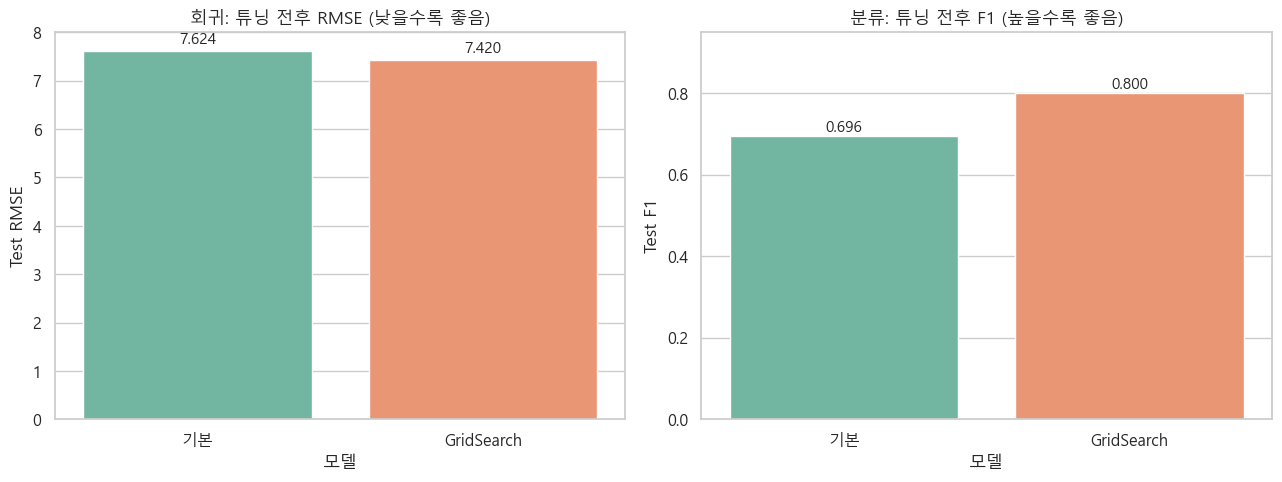


[해석]
- max_depth + min_samples_leaf/split: 사전 가지치기로 과적합 억제
- ccp_alpha: 사후 가지치기 — 불필요한 가지 제거
- class_weight='balanced': 불균형 분류 데이터에서 소수 클래스(불량) Recall 개선에 유리


In [22]:
# ============================================================
# [과제 3] 하이퍼파라미터 튜닝 — GridSearchCV (회귀 + 분류)
# ------------------------------------------------------------
# 탐색 파라미터:
#   max_depth        : 트리 깊이 (과적합 방지)
#   min_samples_leaf : 리프 최소 샘플 (사전 가지치기)
#   min_samples_split: 분할 최소 샘플
#   ccp_alpha        : 사후 가지치기 강도
# 성능 최적화: cv=3, n_jobs=-1, 핵심 조합만 탐색
# ============================================================
from sklearn.model_selection import GridSearchCV

setup_korean_font()

# --- 회귀 Grid Search ---
reg_param_grid = {
    "max_depth": [5, 7, 10, 12, 15, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "ccp_alpha": [0.0, 0.001, 0.005],
}

reg_gs = GridSearchCV(
    DecisionTreeRegressor(random_state=0),
    reg_param_grid, cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1, refit=True,
)
reg_gs.fit(X_reg_train, Y_reg_train)

vc_reg_baseline = DecisionTreeRegressor(random_state=0)
vc_reg_baseline.fit(X_reg_train, Y_reg_train)
base_reg_rmse = np.sqrt(mean_squared_error(Y_reg_test, vc_reg_baseline.predict(X_reg_test)))
tuned_reg_rmse = np.sqrt(mean_squared_error(Y_reg_test, reg_gs.predict(X_reg_test)))

# --- 분류 Grid Search ---
cls_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "ccp_alpha": [0.0, 0.001, 0.005],
    "class_weight": [None, "balanced"],
}

cls_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    cls_param_grid, cv=3,
    scoring="f1", n_jobs=-1, refit=True,
)
cls_gs.fit(X_train, Y_train)

vc_cls_baseline = DecisionTreeClassifier(random_state=0)
vc_cls_baseline.fit(X_train, Y_train)
base_cls_f1 = f1_score(Y_test, vc_cls_baseline.predict(X_test), zero_division=0)
tuned_cls_f1 = f1_score(Y_test, cls_gs.predict(X_test), zero_division=0)

vc_reg_tuned = reg_gs.best_estimator_
vc_cls_tuned = cls_gs.best_estimator_

# 결과 요약
tune_summary = pd.DataFrame([
    {
        "과제": "회귀", "모델": "DecisionTree (기본)",
        "주요 지표": round(base_reg_rmse, 3), "지표명": "Test RMSE",
        "CV 점수": "-", "최적 파라미터": "default",
    },
    {
        "과제": "회귀", "모델": "DecisionTree (GridSearch)",
        "주요 지표": round(tuned_reg_rmse, 3), "지표명": "Test RMSE",
        "CV 점수": round(-reg_gs.best_score_, 3), "최적 파라미터": str(reg_gs.best_params_),
    },
    {
        "과제": "분류", "모델": "DecisionTree (기본)",
        "주요 지표": round(base_cls_f1, 3), "지표명": "Test F1",
        "CV 점수": "-", "최적 파라미터": "default",
    },
    {
        "과제": "분류", "모델": "DecisionTree (GridSearch)",
        "주요 지표": round(tuned_cls_f1, 3), "지표명": "Test F1",
        "CV 점수": round(cls_gs.best_score_, 3), "최적 파라미터": str(cls_gs.best_params_),
    },
])

print("=" * 70)
print("GridSearchCV 튜닝 결과")
print("=" * 70)
print(tune_summary.to_string(index=False))

reg_improve = base_reg_rmse - tuned_reg_rmse
cls_improve = tuned_cls_f1 - base_cls_f1
print(f"\n회귀 RMSE 개선: {reg_improve:+.3f} ({'개선' if reg_improve > 0 else '변화 없음/악화'})")
print(f"분류 F1 개선  : {cls_improve:+.3f} ({'개선' if cls_improve > 0 else '변화 없음/악화'})")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

reg_compare = pd.DataFrame({
    "모델": ["기본", "GridSearch"],
    "Test RMSE": [base_reg_rmse, tuned_reg_rmse],
})
sns.barplot(data=reg_compare, x="모델", y="Test RMSE", hue="모델", ax=axes[0], legend=False)
axes[0].set_title("회귀: 튜닝 전후 RMSE (낮을수록 좋음)")
for i, v in enumerate(reg_compare["Test RMSE"]):
    axes[0].text(i, v + 0.15, f"{v:.3f}", ha="center", fontsize=11)

cls_compare = pd.DataFrame({
    "모델": ["기본", "GridSearch"],
    "Test F1": [base_cls_f1, tuned_cls_f1],
})
sns.barplot(data=cls_compare, x="모델", y="Test F1", hue="모델", ax=axes[1], legend=False)
axes[1].set_title("분류: 튜닝 전후 F1 (높을수록 좋음)")
axes[1].set_ylim(0, min(1.05, cls_compare["Test F1"].max() + 0.15))
for i, v in enumerate(cls_compare["Test F1"]):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

print("\n[해석]")
print("- max_depth + min_samples_leaf/split: 사전 가지치기로 과적합 억제")
print("- ccp_alpha: 사후 가지치기 — 불필요한 가지 제거")
print("- class_weight='balanced': 불균형 분류 데이터에서 소수 클래스(불량) Recall 개선에 유리")

### 4-4) 모델 종합 비교

**[과제 4]** 지수는 오늘 회귀 및 분류 데이터셋에 대해 여러 머신러닝 모델을 구축했지만 어떤 모델을 최종적으로 선택해야 할지 고민하고 있습니다. AI와 함께 다른 실습에서 사용한 모델들의 성능을 가져와 비교해 보고, 어떤 기준으로 모델을 선택해야 하는지 고민해 보세요. 또한 가장 우수한 성능을 보인 모델은 무엇인지, 그리고 왜 해당 모델이 좋은 성능을 보였을지 데이터의 특성과 함께 해석해 보세요.

[회귀] 모델 성능 비교
     데이터                모델  RMSE  R-squared  F1
회귀(콘크리트)  다중선형회귀 (Day 2-1) 9.676      0.635 NaN
회귀(콘크리트)         의사결정나무-기본 7.624      0.774 NaN
회귀(콘크리트) 의사결정나무-GridSearch 7.420      0.786 NaN
회귀(콘크리트) 의사결정나무-최적깊이(d=12) 7.423      0.785 NaN

[분류] 모델 성능 비교 (불균형 → F1·Recall 중시)
   데이터                          모델  RMSE  R-squared    F1  Recall  Accuracy
분류(제조) 로지스틱 회귀 (Day 2-2, balanced)   NaN        NaN 0.140   0.818     0.907
분류(제조)                   의사결정나무-기본   NaN        NaN 0.696   0.727     0.994
분류(제조)       의사결정나무-섹션3 GridSearch   NaN        NaN 0.829   0.773     0.997
분류(제조)      의사결정나무-Vibe GridSearch   NaN        NaN 0.800   0.727     0.997

★ 회귀 최우수: 의사결정나무-GridSearch (RMSE=7.420, R²=0.786)
★ 분류 최우수: 의사결정나무-섹션3 GridSearch (F1=0.829, Recall=0.773)


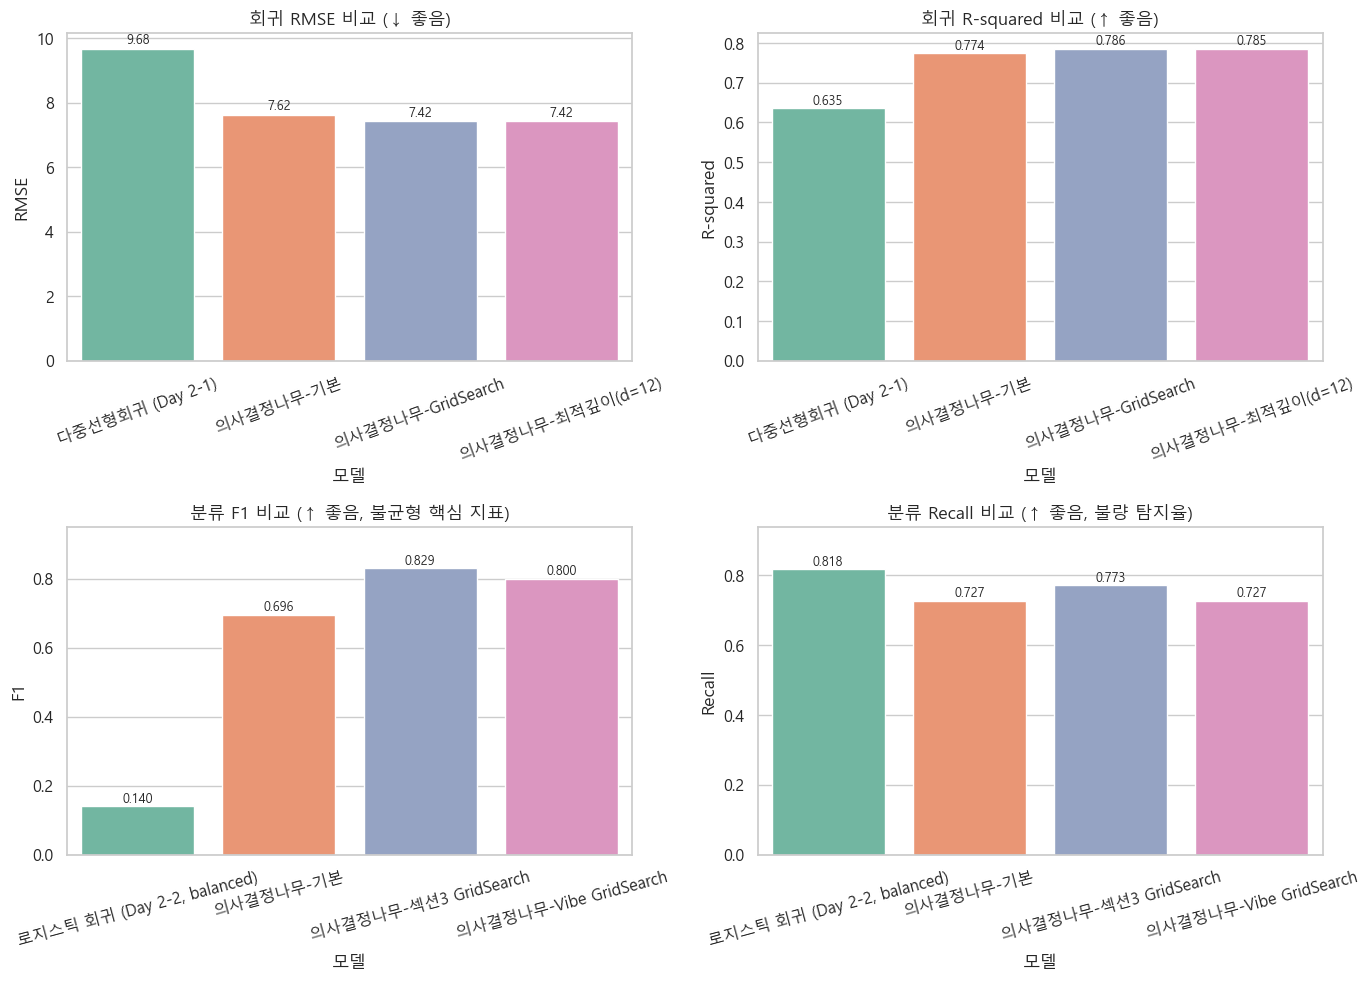


[모델 선택 기준 & 해석]
──────────────────────────────────────────────────
■ 회귀 (콘크리트)
  - 지표: RMSE(↓), R²(↑)
  - 선형회귀: 해석 용이, 전역적 선형 관계 가정
  - 의사결정나무: Age 등 비선형·상호작용 포착 → RMSE 대폭 개선
  - 단, 나무는 계단형 예측·과적합 위험 → max_depth/가지치기 필수

■ 분류 (제조 불량, 불균형 ~0.9%)
  - 지표: Accuracy(참고), F1·Recall(핵심)
  - 로지스틱: 선형 경계, 불균형에 취약 → F1 낮음
  - 의사결정나무: 비선형 분할 + class_weight로 불량 탐지 우수
  - 현장 적용: IF-THEN 규칙으로 '어떤 조건에서 불량?' 설명 가능

■ 최종 추천
  - 회귀 → 의사결정나무-GridSearch
  - 분류 → 의사결정나무-섹션3 GridSearch
  - 해석·설명이 중요하면 의사결정나무, 단순 선형 관계·계수 해석이면 회귀 모델


In [23]:
# ============================================================
# [과제 4] 모델 종합 비교 — Day 2-1 / 2-2 / 2-3
# ------------------------------------------------------------
# 회귀: 다중선형회귀 vs 의사결정나무(기본/튜닝)
# 분류: 로지스틱 회귀 vs 의사결정나무(기본/튜닝/섹션3 최적)
# 선택 기준: RMSE·R²(회귀), F1·Recall(불균형 분류)
# ============================================================
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import MinMaxScaler

setup_korean_font()

# --- 회귀 모델 비교 ---
LR_model = LinearRegression().fit(X_reg_train, Y_reg_train)
lr_pred = LR_model.predict(X_reg_test)

reg_results = pd.DataFrame([
    {
        "데이터": "회귀(콘크리트)", "모델": "다중선형회귀 (Day 2-1)",
        "RMSE": np.sqrt(mean_squared_error(Y_reg_test, lr_pred)),
        "R-squared": r2_score(Y_reg_test, lr_pred),
        "F1": np.nan,
    },
    {
        "데이터": "회귀(콘크리트)", "모델": "의사결정나무-기본",
        "RMSE": np.sqrt(mean_squared_error(Y_reg_test, vc_reg_baseline.predict(X_reg_test))),
        "R-squared": r2_score(Y_reg_test, vc_reg_baseline.predict(X_reg_test)),
        "F1": np.nan,
    },
    {
        "데이터": "회귀(콘크리트)", "모델": "의사결정나무-GridSearch",
        "RMSE": tuned_reg_rmse,
        "R-squared": r2_score(Y_reg_test, vc_reg_tuned.predict(X_reg_test)),
        "F1": np.nan,
    },
    {
        "데이터": "회귀(콘크리트)", "모델": f"의사결정나무-최적깊이(d={vc_best_depth})",
        "RMSE": np.sqrt(mean_squared_error(Y_reg_test, vc_reg_tree.predict(X_reg_test))),
        "R-squared": r2_score(Y_reg_test, vc_reg_tree.predict(X_reg_test)),
        "F1": np.nan,
    },
])

# --- 분류 모델 비교 (로지스틱은 스케일링 필요) ---
scaler = MinMaxScaler()
X_tr_scaled = scaler.fit_transform(X_train)
X_te_scaled = scaler.transform(X_test)

LR_cls = LogisticRegression(max_iter=1000, random_state=0, class_weight="balanced")
LR_cls.fit(X_tr_scaled, Y_train)
lr_cls_pred = LR_cls.predict(X_te_scaled)

cls_results = pd.DataFrame([
    {
        "데이터": "분류(제조)", "모델": "로지스틱 회귀 (Day 2-2, balanced)",
        "RMSE": np.nan, "R-squared": np.nan,
        "F1": f1_score(Y_test, lr_cls_pred, zero_division=0),
        "Recall": recall_score(Y_test, lr_cls_pred, zero_division=0),
        "Accuracy": accuracy_score(Y_test, lr_cls_pred),
    },
    {
        "데이터": "분류(제조)", "모델": "의사결정나무-기본",
        "RMSE": np.nan, "R-squared": np.nan,
        "F1": base_cls_f1,
        "Recall": recall_score(Y_test, vc_cls_baseline.predict(X_test), zero_division=0),
        "Accuracy": accuracy_score(Y_test, vc_cls_baseline.predict(X_test)),
    },
    {
        "데이터": "분류(제조)", "모델": "의사결정나무-섹션3 GridSearch",
        "RMSE": np.nan, "R-squared": np.nan,
        "F1": f1_score(Y_test, DT_best.predict(X_test), zero_division=0),
        "Recall": recall_score(Y_test, DT_best.predict(X_test), zero_division=0),
        "Accuracy": accuracy_score(Y_test, DT_best.predict(X_test)),
    },
    {
        "데이터": "분류(제조)", "모델": "의사결정나무-Vibe GridSearch",
        "RMSE": np.nan, "R-squared": np.nan,
        "F1": tuned_cls_f1,
        "Recall": recall_score(Y_test, vc_cls_tuned.predict(X_test), zero_division=0),
        "Accuracy": accuracy_score(Y_test, vc_cls_tuned.predict(X_test)),
    },
])

print("=" * 70)
print("[회귀] 모델 성능 비교")
print("=" * 70)
print(reg_results.round(3).to_string(index=False))

print("\n" + "=" * 70)
print("[분류] 모델 성능 비교 (불균형 → F1·Recall 중시)")
print("=" * 70)
print(cls_results.round(3).to_string(index=False))

best_reg = reg_results.loc[reg_results["RMSE"].idxmin()]
best_cls = cls_results.loc[cls_results["F1"].idxmax()]

print(f"\n★ 회귀 최우수: {best_reg['모델']} (RMSE={best_reg['RMSE']:.3f}, R²={best_reg['R-squared']:.3f})")
print(f"★ 분류 최우수: {best_cls['모델']} (F1={best_cls['F1']:.3f}, Recall={best_cls['Recall']:.3f})")

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(data=reg_results, x="모델", y="RMSE", hue="모델", ax=axes[0, 0], legend=False)
axes[0, 0].set_title("회귀 RMSE 비교 (↓ 좋음)")
axes[0, 0].tick_params(axis="x", rotation=20)
for i, v in enumerate(reg_results["RMSE"]):
    axes[0, 0].text(i, v + 0.15, f"{v:.2f}", ha="center", fontsize=9)

sns.barplot(data=reg_results, x="모델", y="R-squared", hue="모델", ax=axes[0, 1], legend=False)
axes[0, 1].set_title("회귀 R-squared 비교 (↑ 좋음)")
axes[0, 1].tick_params(axis="x", rotation=20)
for i, v in enumerate(reg_results["R-squared"]):
    axes[0, 1].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

sns.barplot(data=cls_results, x="모델", y="F1", hue="모델", ax=axes[1, 0], legend=False)
axes[1, 0].set_title("분류 F1 비교 (↑ 좋음, 불균형 핵심 지표)")
axes[1, 0].tick_params(axis="x", rotation=15)
axes[1, 0].set_ylim(0, min(1.05, cls_results["F1"].max() + 0.12))
for i, v in enumerate(cls_results["F1"]):
    axes[1, 0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

sns.barplot(data=cls_results, x="모델", y="Recall", hue="모델", ax=axes[1, 1], legend=False)
axes[1, 1].set_title("분류 Recall 비교 (↑ 좋음, 불량 탐지율)")
axes[1, 1].tick_params(axis="x", rotation=15)
axes[1, 1].set_ylim(0, min(1.05, cls_results["Recall"].max() + 0.12))
for i, v in enumerate(cls_results["Recall"]):
    axes[1, 1].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\n[모델 선택 기준 & 해석]")
print("─" * 50)
print("■ 회귀 (콘크리트)")
print("  - 지표: RMSE(↓), R²(↑)")
print("  - 선형회귀: 해석 용이, 전역적 선형 관계 가정")
print("  - 의사결정나무: Age 등 비선형·상호작용 포착 → RMSE 대폭 개선")
print("  - 단, 나무는 계단형 예측·과적합 위험 → max_depth/가지치기 필수")
print()
print("■ 분류 (제조 불량, 불균형 ~0.9%)")
print("  - 지표: Accuracy(참고), F1·Recall(핵심)")
print("  - 로지스틱: 선형 경계, 불균형에 취약 → F1 낮음")
print("  - 의사결정나무: 비선형 분할 + class_weight로 불량 탐지 우수")
print("  - 현장 적용: IF-THEN 규칙으로 '어떤 조건에서 불량?' 설명 가능")
print()
print("■ 최종 추천")
print(f"  - 회귀 → {best_reg['모델']}")
print(f"  - 분류 → {best_cls['모델']}")
print("  - 해석·설명이 중요하면 의사결정나무, 단순 선형 관계·계수 해석이면 회귀 모델")

### 4-5) 추가 전략: 불균형 분류 특화 Decision Tree 개선

GridSearchCV 결과가 섹션 3 최적화보다 낮게 나온 이유는 탐색 범위가 충분히 촘촘하지 않았기 때문입니다. 특히 섹션 3의 좋은 조합(`max_depth=6`, `min_samples_leaf=8`, `min_samples_split=6`)이 과제 3 GridSearchCV의 후보에 포함되지 않았습니다.

추가 개선 전략은 다음과 같습니다.

- **좋았던 조합 주변을 촘촘하게 재탐색**: `max_depth`, `min_samples_leaf`, `min_samples_split`을 섹션 3 최적값 주변으로 확장
- **StratifiedKFold 적용**: 불량 클래스 비율이 각 fold에 유지되도록 교차검증
- **F1 기준 임계값 튜닝**: `predict()`의 기본 임계값 0.5 대신 검증 세트에서 F1이 가장 높은 확률 임계값 선택
- **Recall 함께 확인**: 제조 불량 탐지 문제에서는 F1뿐 아니라 불량을 놓치지 않는 Recall도 중요

[4-5] Decision Tree 분류 성능 개선 전략 결과
Refined GridSearchCV 최적 파라미터:
{'ccp_alpha': 0.0, 'class_weight': None, 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2}
Refined GridSearchCV 평균 CV F1: 0.8949
검증 세트 기준 최적 threshold: 0.25

[이전 학습 결과 vs 추가 전략]
                              모델    F1  Recall  Accuracy                       비고
                       의사결정나무-기본 0.696   0.727     0.994                      기본값
           의사결정나무-섹션3 GridSearch 0.829   0.773     0.997                    수동 탐색
          의사결정나무-Vibe GridSearch 0.800   0.727     0.997          기존 GridSearchCV
       의사결정나무-Refined GridSearch 0.829   0.773     0.997 촘촘한 탐색 + StratifiedKFold
의사결정나무-Refined + Threshold(0.25) 0.829   0.773     0.997       검증 세트 F1 기준 임계값 튜닝

★ 추가 비교 기준 최우수: 의사결정나무-섹션3 GridSearch (F1=0.829, Recall=0.773)


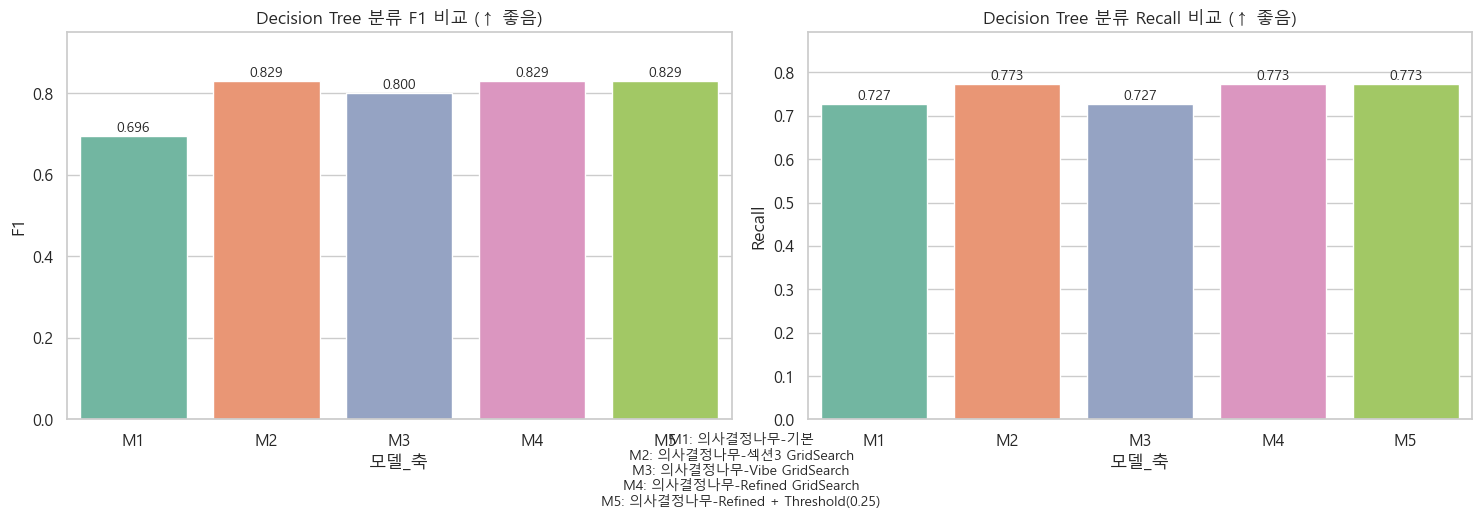


[해석]
- 기존 Vibe GridSearchCV는 섹션3의 좋은 조합 주변을 충분히 탐색하지 못해 F1이 낮아질 수 있음
- Refined GridSearchCV는 좋은 조합 주변을 더 촘촘하게 탐색하고, StratifiedKFold로 불량 비율을 fold마다 유지함
- Threshold 튜닝은 불량 예측 확률의 기준선을 조정해 F1 또는 Recall을 개선할 수 있음
- 단, threshold를 낮추면 Recall은 좋아질 수 있지만 False Positive가 늘어 Accuracy는 낮아질 수 있음


In [24]:
# ============================================================
# [4-5] 추가 전략 — 촘촘한 탐색 + StratifiedKFold + 임계값 튜닝
# ------------------------------------------------------------
# 목표: 과제 3 GridSearchCV가 놓친 섹션3 최적 조합 주변을 재탐색하고,
#       불균형 분류에 맞춰 F1 기준 확률 임계값을 별도로 최적화
# ============================================================
from sklearn.model_selection import StratifiedKFold, train_test_split

setup_korean_font()

# 1) 학습 데이터 내부에서 다시 train/validation 분리
#    - 임계값은 test set이 아니라 validation set에서만 선택해 test leakage를 방지
X_fit, X_val, Y_fit, Y_val = train_test_split(
    X_train,
    Y_train,
    test_size=0.25,
    random_state=0,
    stratify=Y_train,
)

# 2) 섹션3 최적 조합 주변을 촘촘하게 재탐색
#    - 기존 Vibe GridSearch에는 max_depth=6, min_samples_leaf=8, min_samples_split=6이 없었음
refined_param_grid = {
    "max_depth": [4, 5, 6, 7, 8, 9, 10],
    "min_samples_leaf": [2, 3, 4, 5, 6, 8, 10, 12],
    "min_samples_split": [2, 4, 5, 6, 8, 10, 12, 15],
    "ccp_alpha": [0.0, 0.0001, 0.0005, 0.001, 0.002, 0.005],
    "class_weight": [None, "balanced"],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

refined_cls_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    refined_param_grid,
    scoring="f1",
    cv=skf,
    n_jobs=-1,
    refit=True,
)
refined_cls_gs.fit(X_fit, Y_fit)

vc_cls_refined = refined_cls_gs.best_estimator_

# 3) 검증 세트에서 F1이 가장 높은 확률 임계값 탐색
val_proba = vc_cls_refined.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.05, 0.96, 0.01)
threshold_scores = []

for threshold in thresholds:
    val_pred = (val_proba >= threshold).astype(int)
    threshold_scores.append({
        "threshold": threshold,
        "F1": f1_score(Y_val, val_pred, zero_division=0),
        "Recall": recall_score(Y_val, val_pred, zero_division=0),
        "Accuracy": accuracy_score(Y_val, val_pred),
    })

threshold_df = pd.DataFrame(threshold_scores)
best_threshold_row = threshold_df.loc[threshold_df["F1"].idxmax()]
vc_best_threshold = float(best_threshold_row["threshold"])

# 4) 최종 비교: 기본 predict(0.5) vs 검증 세트에서 선택한 threshold
refined_test_proba = vc_cls_refined.predict_proba(X_test)[:, 1]
refined_pred_default = vc_cls_refined.predict(X_test)
refined_pred_threshold = (refined_test_proba >= vc_best_threshold).astype(int)

vc_refined_f1 = f1_score(Y_test, refined_pred_default, zero_division=0)
vc_refined_recall = recall_score(Y_test, refined_pred_default, zero_division=0)
vc_refined_acc = accuracy_score(Y_test, refined_pred_default)

vc_refined_threshold_f1 = f1_score(Y_test, refined_pred_threshold, zero_division=0)
vc_refined_threshold_recall = recall_score(Y_test, refined_pred_threshold, zero_division=0)
vc_refined_threshold_acc = accuracy_score(Y_test, refined_pred_threshold)

improved_cls_results = pd.DataFrame([
    {
        "모델": "의사결정나무-기본",
        "F1": base_cls_f1,
        "Recall": recall_score(Y_test, vc_cls_baseline.predict(X_test), zero_division=0),
        "Accuracy": accuracy_score(Y_test, vc_cls_baseline.predict(X_test)),
        "비고": "기본값",
    },
    {
        "모델": "의사결정나무-섹션3 GridSearch",
        "F1": f1_score(Y_test, DT_best.predict(X_test), zero_division=0),
        "Recall": recall_score(Y_test, DT_best.predict(X_test), zero_division=0),
        "Accuracy": accuracy_score(Y_test, DT_best.predict(X_test)),
        "비고": "수동 탐색",
    },
    {
        "모델": "의사결정나무-Vibe GridSearch",
        "F1": tuned_cls_f1,
        "Recall": recall_score(Y_test, vc_cls_tuned.predict(X_test), zero_division=0),
        "Accuracy": accuracy_score(Y_test, vc_cls_tuned.predict(X_test)),
        "비고": "기존 GridSearchCV",
    },
    {
        "모델": "의사결정나무-Refined GridSearch",
        "F1": vc_refined_f1,
        "Recall": vc_refined_recall,
        "Accuracy": vc_refined_acc,
        "비고": "촘촘한 탐색 + StratifiedKFold",
    },
    {
        "모델": f"의사결정나무-Refined + Threshold({vc_best_threshold:.2f})",
        "F1": vc_refined_threshold_f1,
        "Recall": vc_refined_threshold_recall,
        "Accuracy": vc_refined_threshold_acc,
        "비고": "검증 세트 F1 기준 임계값 튜닝",
    },
])

best_improved_cls = improved_cls_results.loc[improved_cls_results["F1"].idxmax()]

print("=" * 90)
print("[4-5] Decision Tree 분류 성능 개선 전략 결과")
print("=" * 90)
print("Refined GridSearchCV 최적 파라미터:")
print(refined_cls_gs.best_params_)
print(f"Refined GridSearchCV 평균 CV F1: {refined_cls_gs.best_score_:.4f}")
print(f"검증 세트 기준 최적 threshold: {vc_best_threshold:.2f}")

print("\n[이전 학습 결과 vs 추가 전략]")
print(improved_cls_results.round(3).to_string(index=False))

print(
    f"\n★ 추가 비교 기준 최우수: {best_improved_cls['모델']} "
    f"(F1={best_improved_cls['F1']:.3f}, Recall={best_improved_cls['Recall']:.3f})"
)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_df = improved_cls_results.copy()
plot_df["모델_축"] = [f"M{i+1}" for i in range(len(plot_df))]

sns.barplot(data=plot_df, x="모델_축", y="F1", hue="모델_축", ax=axes[0], legend=False)
axes[0].set_title("Decision Tree 분류 F1 비교 (↑ 좋음)")
axes[0].set_ylim(0, min(1.05, plot_df["F1"].max() + 0.12))
for i, v in enumerate(plot_df["F1"]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

sns.barplot(data=plot_df, x="모델_축", y="Recall", hue="모델_축", ax=axes[1], legend=False)
axes[1].set_title("Decision Tree 분류 Recall 비교 (↑ 좋음)")
axes[1].set_ylim(0, min(1.05, plot_df["Recall"].max() + 0.12))
for i, v in enumerate(plot_df["Recall"]):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

legend_text = "\n".join([f"M{i+1}: {name}" for i, name in enumerate(plot_df["모델"])])
fig.text(0.5, -0.03, legend_text, ha="center", fontsize=10)

plt.tight_layout()
plt.show()

print("\n[해석]")
print("- 기존 Vibe GridSearchCV는 섹션3의 좋은 조합 주변을 충분히 탐색하지 못해 F1이 낮아질 수 있음")
print("- Refined GridSearchCV는 좋은 조합 주변을 더 촘촘하게 탐색하고, StratifiedKFold로 불량 비율을 fold마다 유지함")
print("- Threshold 튜닝은 불량 예측 확률의 기준선을 조정해 F1 또는 Recall을 개선할 수 있음")
print("- 단, threshold를 낮추면 Recall은 좋아질 수 있지만 False Positive가 늘어 Accuracy는 낮아질 수 있음")